In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.metrics import r2_score 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian, decimate
from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

import warnings
warnings.filterwarnings("ignore")
torch.set_warn_always(False)

%matplotlib inline
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

### Load spikes and neuromodulation signal

In [2]:
data_dir = '../../data/recordings/nk340_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_669, 7_869
bin_size = 0.05
bs = 512 # batch size 
fr_threshold = 0.5

threshold_neurons = True
z_score = False
deconvolve = False 
convolve_spikes = True
normalize_neuromod = True
center = False

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'electrophysiology')
    files = [f for f in os.listdir(spikes_dir) if os.path.isfile(os.path.join(spikes_dir, f))]
    files = sorted(files)
    t_start, t_end = 0, 0
    for f in files:
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))
    
    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)
    if threshold_neurons:
        rates = spike_counts.mean(axis=1) / bin_size 
        low_firing = np.where(rates < fr_threshold)[0] 
        print(f'{len(low_firing)} neurons removed') 
        spike_counts = np.delete(spike_counts, low_firing, axis=0)
    print(np.isnan(spike_counts).any())
    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved_2.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_full.csv', header=None).to_numpy().flatten()
    # downsample
    fs, target_fs = 1000, 1 / bin_size
    downsample_factor = int(fs / target_fs)
    downsampled_signal = decimate(lc_neuromod, downsample_factor, ftype='fir', zero_phase=True)
    print(f'length of downsampled signal: {len(downsampled_signal)}')
    print(f'length of original signal: {len(lc_neuromod)}') 
    lc_neuromod = downsampled_signal 
    
    # select in window 
    lc_neuromod = lc_neuromod[int(t_start/bin_size):int(t_end/bin_size)]
    # replace nans with zero 
    lc_neuromod = np.nan_to_num(lc_neuromod)
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else:
        neuromod_activity = lc_neuromod
    # center 
    if center:
        neuromod_activity += np.abs(neuromod_activity.min())
    # mean-center the neurons 
    spike_counts = spike_counts - spike_counts.mean(axis=1, keepdims=True)
    # spike_counts = (spike_counts - np.expand_dims(spike_counts.mean(axis=1), -1)) / np.expand_dims(spike_counts.std(axis=1), -1)
    print(np.isnan(spike_counts).any())
    if convolve_spikes:
        kernel_size = 25
        sigma = 5
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
    # load trials info 
    print(np.isnan(spike_counts).any())
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [ ]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 5183
174 neurons removed
False


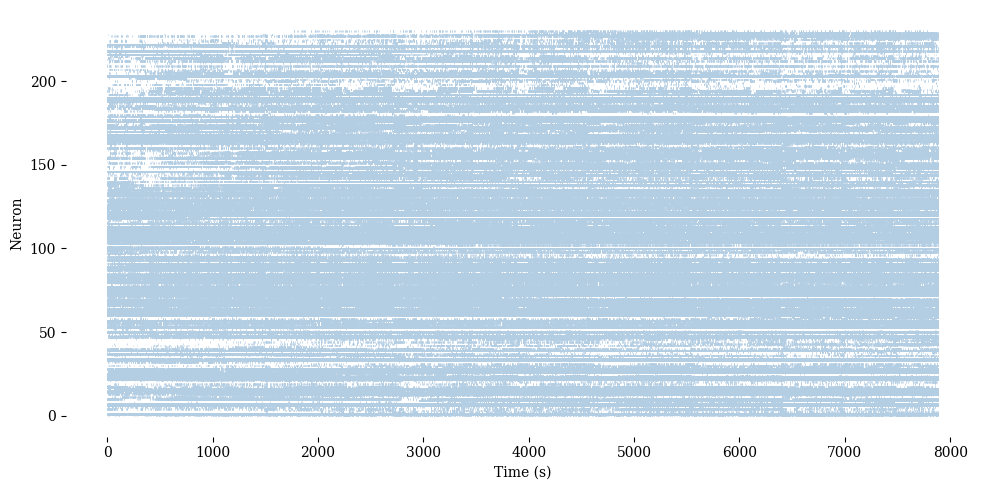

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

### Split baseline period into training and testing samples and filter out neurons with little activity

In [5]:
"""
stimulus array contains 9 variables
stimulus 0 - tone 1
stimulus 1 - tone 2
stimulus 2 - tone 3
stimulus 3 - white noise 
stimulus 4 - airpuff 
stimulus 5 - 5% sucrose 
stimulus 6 - 10% sucrose 
stimulus 7 - quinine
stimulus 8 - odor 
"""
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

def get_trial_blocks(trial_type):
    trial_times = trials_df[trials_df['trialtype'] == trial_type]['t'].astype('int').to_list()
    trial_blocks = []
    for t in trial_times:
        t_start, t_end = t - 10, t + 10
        trial_blocks.append([t_start, t_end])
    return trial_blocks

def get_white_noise_trial(cs):
    trial_dur = 6
    stim_arr_white_noise = np.zeros((9, int(trial_dur / bin_size),))
    trial_start = cs 
    pip_dur = 100 
    pip_interval = 200 
    stim_idx = 0
    for i in range(20):
        stim_arr_white_noise[3, int(stim_idx + pip_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(pip_dur / (bin_size * 1000)) + int(pip_interval / (bin_size * 1000))
    return stim_arr_white_noise

def get_airpuff_trial(cs, us):
    trial_dur = 13.5 # 13.5 seconds 
    tone_dur = 100 # 100 ms  
    airpuff_dur = 100 # 100 ms 
    airpuff_interval = 100 # 100 ms 
    tone_interval = 900 
    
    stim_arr_airpuff = np.zeros((9, int(trial_dur / bin_size),))
    stim_idx = 0
    for i in range(10):
        stim_arr_airpuff[2, int(stim_idx):int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(tone_interval / (bin_size * 1000))
    # now add the unconditioned stimulus 
    stim_idx = (us - cs) / bin_size 
    for i in range(15):
        stim_arr_airpuff[4, int(stim_idx):int(stim_idx + airpuff_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(airpuff_dur / (bin_size * 1000)) + int(airpuff_interval / (bin_size * 1000))
    return stim_arr_airpuff

def get_reward_block(block_idx):
    block_start_idx = 7 * block_idx 
    trial_dur = 215 # 215s
    tone_dur = 1000 # 1000 ms
    lag_dur = 500 # 500 ms
    reward_dur = 2000 # 2000

    stim_arr_reward = np.zeros((9, int(trial_dur / bin_size),))
    trial_blocks = []
    # Add 4 trials of reward 1
    reward_1_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1']['cs'].to_list()[block_start_idx:block_start_idx + 7]
    for i in range(4):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
        
    # omission (tone without reward)
    omission_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_2500']['cs'].to_list()[block_idx]
    trial_start = (omission_onset - reward_1_us[0]) / bin_size 
    stim_idx = int(trial_start) 
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    trial_blocks.append([trial_start, int(stim_idx + tone_dur / (bin_size * 1000))])

    # reward 2 
    reward_2_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_2_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx*3:block_idx*3 +3]
    for i in range(3):
        trial_start = (reward_2_us[i] - reward_1_us[0]) // bin_size 
        stim_idx = int(trial_start)
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # provide 10% sucrose drop 
        stim_arr_reward[6, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0 
        stim_idx += reward_dur / (bin_size * 1000)
        trial_blocks.append([trial_start, int(stim_idx)])
        
    # quinine 
    quinine_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_3_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx]
    trial_start = (quinine_onset - reward_1_us[0]) / bin_size
    stim_idx = int(trial_start)
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
    # provide quinine drop 
    stim_arr_reward[7, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0    
    stim_idx += int(reward_dur / (bin_size * 1000))
    trial_blocks.append([trial_start, stim_idx])

    # reward 1 again 
    for i in range(4, 7):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
    return stim_arr_reward, trial_blocks, reward_1_us[0]



## Analysis of models trained on baseline period

In [33]:
# define training samples
x_train = None 
s_train = None 
stim_arr_train = None 

spike_counts_baseline, s_baseline = get_block(spike_counts, neuromod_activity, t_start_baseline, t_end_baseline)
x_train = [spike_counts_baseline]
s_train = [s_baseline]
stim_arr_train = [np.zeros((9, s_baseline.shape[0]))]
seq_periods = [[0, s_baseline.shape[0]]]

spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
x_train.append(spike_counts_pt_baseline)
s_train.append(s_pt_baseline)
stim_arr_train.append(np.zeros((9, s_pt_baseline.shape[0])))
seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_pt_baseline.shape[0]])

# get first 4 white noise blocks 
white_noise_trial_dur = 6 # 6 seconds
white_noise_trials_cs = trials_df[trials_df['trialtype'] == 'TONE_2']['cs'].to_list()

for trial_idx, trial in enumerate(white_noise_trials_cs):
    spike_counts_white_noise, s_white_noise = get_block(spike_counts, neuromod_activity, trial, trial + white_noise_trial_dur)
    # get stimulus 
    stim_white_noise_trial = get_white_noise_trial(trial) 
    x_train.append(spike_counts_white_noise)
    s_train.append(s_white_noise) 
    stim_arr_train.append(stim_white_noise_trial) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_white_noise.shape[0]])

# get first 3 airpuff blocks 
airpuff_trial_dur = 13.5
airpuff_trial_cs = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['cs'].to_list()
airpuff_trial_us = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['us'].to_list()

for trial_idx, trial in enumerate(airpuff_trial_cs):
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, trial, trial + airpuff_trial_dur)
    us = airpuff_trial_us[trial_idx]
    stim_airpuff = get_airpuff_trial(trial, us) 

    x_train.append(spike_counts_airpuff)
    s_train.append(s_airpuff) 
    stim_arr_train.append(stim_airpuff) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_airpuff.shape[0]])

for i in range(7):
    # get stimuli 
    stim_arr_rewards, trial_blocks, reward_trial_start = get_reward_block(i)
    spike_counts_reward, s_reward = get_block(spike_counts, neuromod_activity,reward_trial_start, reward_trial_start + 215)
    # s_reward = (s_reward - s_reward.min()) / (s_reward.max() - s_reward.min()) 
    
    x_train.append(spike_counts_reward)
    s_train.append(s_reward)
    temp_arr = np.hstack([zero_arr, stim_arr_rewards, zero_arr])
    stim_arr_train.append(stim_arr_rewards)
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_reward.shape[0]])
        
x_train = np.hstack(x_train)
s_train = np.hstack(s_train) 
stim_arr_train = np.hstack(stim_arr_train) 

# normalize neuromdoulators 
max_neuromod = s_train.max()
min_neuromod = s_train.min()
s_train = (s_train - s_train.min()) / (s_train.max() - s_train.min())

In [7]:
# define training samples
x_train = None 
s_train = None 
stim_arr_train = None 

spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
x_train = [spike_counts_pt_baseline]
s_train = [s_pt_baseline] 
stim_arr_train = [np.zeros((9, s_pt_baseline.shape[0]))]
seq_periods = [[0, s_pt_baseline.shape[0]]]
# get first 4 white noise blocks 
white_noise_trial_dur = 6 # 6 seconds
white_noise_trials_cs = trials_df[trials_df['trialtype'] == 'TONE_2']['cs'].to_list()
zero_arr = np.zeros((9, int(15 / bin_size))) 

for trial_idx, trial in enumerate(white_noise_trials_cs):
    spike_counts_white_noise, s_white_noise = get_block(spike_counts, neuromod_activity, trial, trial + white_noise_trial_dur)
    # get stimulus 
    stim_white_noise_trial = get_white_noise_trial(trial) 
    x_train.append(spike_counts_white_noise)
    s_train.append(s_white_noise) 
    stim_arr_train.append(stim_white_noise_trial) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_white_noise.shape[0]])

# get first 3 airpuff blocks 
airpuff_trial_dur = 13.5
airpuff_trial_cs = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['cs'].to_list()
airpuff_trial_us = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['us'].to_list()

for trial_idx, trial in enumerate(airpuff_trial_cs):
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, trial, trial + airpuff_trial_dur)
    us = airpuff_trial_us[trial_idx]
    stim_airpuff = get_airpuff_trial(trial, us) 

    x_train.append(spike_counts_airpuff)
    s_train.append(s_airpuff) 
    stim_arr_train.append(stim_airpuff) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_airpuff.shape[0]])

# get first 4 reward blocks
# fig, ax = plt.subplots(4, 1, figsize=(10, 15))
reward_eval_blocks = []
for i in range(7):
    # get stimuli 
    stim_arr_rewards, trial_blocks, reward_trial_start = get_reward_block(i)
    spike_counts_reward, s_reward = get_block(spike_counts, neuromod_activity,reward_trial_start, reward_trial_start + 215)
    # s_reward = (s_reward - s_reward.min()) / (s_reward.max() - s_reward.min()) 
    
    x_train.append(spike_counts_reward)
    s_train.append(s_reward)
    stim_arr_train.append(stim_arr_rewards)
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_reward.shape[0]])

    reward_eval_blocks.append(trial_blocks)

x_train = np.hstack(x_train)
s_train = np.hstack(s_train) 
stim_arr_train = np.hstack(stim_arr_train) 
max_neuromod = s_train.max()
min_neuromod = s_train.min()
# normalize neuromdoulators 
s_train = (s_train - s_train.min()) / (s_train.max() - s_train.min())

### Load models

In [8]:
models = {}
# neuromodulation = ['None', 'additive', 'postsynaptic', 'presynaptic', 'rank']
# for neuromod in neuromodulation:
#     try:
#         vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{neuromod}_rank_20_147_baseline')
#         models[neuromod] = vae
#     except: 
#         print(f'Not found: {neuromod}')  

vae, params, task_params, training_params = load_model(f'../../models/dtt/all_None_rank_20_147_stim_2')
models['None_stim'] = vae

vae, params, task_params, training_params = load_model(f'../../models/dtt/all_postsynaptic_rank_20_147_neuromod_stim_2')
models['postsynaptic_stim'] = vae
vae, params, task_params, training_params = load_model(f'../../models/dtt/all_postsynaptic_rank_20_147_neuromod_2')
models['postsynaptic'] = vae
vae, params, task_params, training_params = load_model(f'../../models/dtt/all_additive_rank_20_147_neuromod_2')
models['additive'] = vae
vae, params, task_params, training_params = load_model(f'../../models/dtt/all_additive_rank_20_147_neuromod_stim_2')
models['additive_stim'] = vae
# vae, params, task_params, training_params = load_model(f'../../models/dtt/all_presynaptic_rank_20_147_neuromod_stim')
# models['presynaptic'] = vae
# vae, params, task_params, training_params = load_model(f'../../models/dtt/all_rank_rank_20_147_neuromod_stim')
# models['rank_stim'] = vae
# vae, params, task_params, training_params = load_model(f'../../models/dtt/all_rank_rank_20_147_neuromod')
# models['rank'] = vae

/network/iss/home/kaleab.belay/mnm/train_scripts/recordings/../../vi_rnn/saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 

In [253]:
models.keys()

dict_keys(['None_stim', 'postsynaptic_stim', 'postsynaptic', 'additive', 'additive_stim'])

### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [7]:
def get_trajectory(t_start, t_end, vae, neuromod, stim, use_index=False):
    """
    Args:
        t_start (int): bin index in which to start the trajectory
        t_end (int): bin index in which to end the trajectory 
        vae (VAE): the model 
        neuromod: the neuromodulation type
    Returns:
        obs (torch.tensor; num_neurons x T): Generated trajectory
    """
    if use_index:
        spike_counts_val, neuromod_val = x_train[:, t_start:t_end], s_train[t_start:t_end]
        s_test_block = torch.from_numpy(neuromod_val).view(1, 1, -1).to(torch.float32)
    else:
        spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
        s_test_block = None 
        
    T = neuromod_val.shape[0]
    spike_counts_val = torch.from_numpy(spike_counts_val).to(torch.float32)
    z_hat, _, _, _ = vae.encoder(spike_counts_val.unsqueeze(0))
    z0 = z_hat[:, :, 0].squeeze()
    if stim is not None:
        sim_v = True
    else:
        stim=None 
        sim_v = False
    if 'deconv' in neuromod:
        s_test_block = torch.from_numpy(neuromod_activity_deconv_val).to(torch.float32).view(1, 1, -1)
    elif 'whisking' in neuromod:
        s_test_block = torch.from_numpy(whisking_val).to(torch.float32).view(1, 1, -1)
    elif 'None' not in neuromod and use_index == False:
        s_test_block = torch.from_numpy(neuromod_val).to(torch.float32).view(1, 1, -1)
        s_test_block = (s_test_block - min_neuromod) / (max_neuromod - min_neuromod) 
    if 'additive' in neuromod:
        if stim is None:
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s=True)
            # print(type(S))
            # print(S)
            obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else:
            Z, V, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim.unsqueeze(0), s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s=True)
            obs = vae.rnn.get_observation(Z, s=S, v=V, noise_scale=0)[0, :, :, 0]
    elif 'None' in neuromod:
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, noise_scale=1, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:   
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim if stim is None else stim.unsqueeze(0), noise_scale=1, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    else: 
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim if stim is None else stim.unsqueeze(0), s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    return obs 

In [21]:
def plot_bar(stats: np.array, block_idx: int, title, width=0.4):
    means = [stats[model].mean(axis=0)[block_idx] for model in stats.keys()]
    stds = [stats[model].std(axis=0)[block_idx] for model in stats.keys()] 
    std_err = [stds[i] / len(stats[model]) for i, model in enumerate(stats.keys())]

    x = np.arange(len(means))
    fig, ax = plt.subplots(figsize=(10,8))
    ax.bar(x, means, width, yerr=std_err, alpha=0.7, capsize=5)

    for i, cat in enumerate(stats.keys()):
        x_jittered = x[i] + np.random.uniform(-width/4, width/4, stats[cat].shape[0])
        ax.scatter(x_jittered, stats[cat][:, block_idx], s=10)
    ax.set_xticklabels(list(model_mres.keys()))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xticks(x)
    ax.set_title(title, fontsize=15)

def plot_group_bar(stats: np.array, title, width=0.1):
    means = {block: [stats[model].mean(axis=0)[block] for model in stats.keys()] for block in range(3)}
    stds = {block: [stats[model].std(axis=0)[block] for model in stats.keys()] for block in range(3)}
    
    x = np.arange(len(list(means.keys())))
    print(len(x))
    fig, ax = plt.subplots(figsize=(10, 8)) 
    for i, group in enumerate(stats.keys()):
        offsets = x - width / 2 + i * width 
        mean_values = [means[block][i] for block in range(len(list(means.keys())))]
        ax.bar(offsets, mean_values, width, label=group, alpha=0.7)

In [ ]:
model_kl_divs, model_mres, model_pshs

In [ ]:
plot_bar(model_mres, 0, 'Mean-rate error')

In [ ]:
plot_bar(model_kl_divs, 0, 'KL-Divergence')

In [ ]:
plot_bar(model_pshs, 0, 'Hellinger Distance')

In [ ]:
model_set

In [69]:
def plot_raw_traces(tch, num_neurons, num_cols, column_titles, stud, figsize=(6, 6), T=1000):
    num_rows, num_cols = num_neurons, num_cols
    with plt.rc_context({'font.size': 4}):
        fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        c = ['r', 'g', 'blue', 'black', 'orange', 'brown']
        column_titles = ["Ground Truth"] + list(column_titles) 
        print(column_titles)
        neurons = np.random.choice(range(0, 94), size=num_neurons, replace=False)
        # Set titles for the top row
        for col, title in enumerate(column_titles):
            ax[0, col].set_title(title, fontsize=12)
        for i, neuron in enumerate(neurons):
            ax[i, 0].plot(tch[neuron, :T], c=c[0])
            ymin, ymax = tch[neuron, :].min(), tch[neuron, :].max()
            for j in range(len(model_set)):
                ax[i, j+1].plot(stud[j][neuron, :T], label=list(model_set)[j], c=c[j+1])
                ymin = min(ymin, stud[j][neuron, :T].min())
                ymax = max(ymax, stud[j][neuron, :T].max())
                # ax[i, j+1].set_yticks([])
            for j in range(0, len(list(model_set)) + 1):
                ax[i, j].set_ylim(ymin, ymax)
                ax[i, j].set_xticks([])
                if j == 0:
                    ax[i, j].set_yticks([round(ymin.item(), 1), round(ymax.item(), 1)])
                ax[i, j].tick_params(axis='both', labelsize=7)
        # plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    # fig.savefig('traces.svg', format='svg', bbox_inches='tight')

In [10]:
def compute_population_cross_corr(sig1, sig2):
    corrs = []
    for i in range(sig1.shape[0]):
        corrs.append(np.correlate(sig1[i], sig2, mode='full'))
    return np.array(corrs)

### Compute psth around neuromodulator peaks

In [21]:
def compute_LC_trig_activity(traj, neuromod_val, dur=200): 
    neuromod_zsc = (neuromod_val - neuromod_val.mean()) / neuromod_val.std() 
    # take everything above 2 standard deviations 
    neuromod_peaks = np.where(neuromod_zsc > 3)[0]
    psths_val = np.zeros((len(neuromod_peaks), traj.shape[0], dur))
    nrpn = np.zeros((len(neuromod_peaks), dur))
    for i, peak in enumerate(neuromod_peaks):
        psths_val[i] = traj[:, peak - dur // 2:peak + dur // 2]
        nrpn[i] = neuromod_val[peak - dur // 2:peak + dur // 2]
    psths_val = psths_val.mean(axis=0)
    # sort by time of peak
    max_indices = np.argmax(psths_val, axis=1)
    psths_sorted = psths_val[np.argsort(max_indices)]
    psths_sorted = (psths_sorted - psths_sorted.mean(axis=1, keepdims=True)) / psths_sorted.std(axis=1, keepdims=True)
    nrpn = nrpn.mean(axis=0)
    return psths_val, psths_sorted, nrpn, max_indices

6069 6669
(147, 12000)


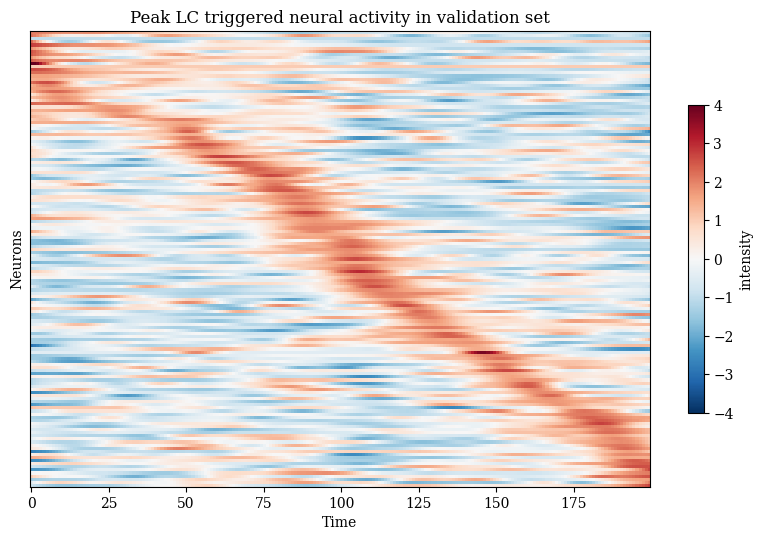

In [22]:
t_start, t_end = t_start_post_trial - 600, t_start_post_trial 
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
print(t_start, t_end)
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
print(spike_counts_val.shape)
_, psths_val, nrpn, ind_test = compute_LC_trig_activity(spike_counts_val, neuromod_val, dur=200)
psths_val = np.nan_to_num(psths_val)
# partial z_score each row
fig, ax = plt.subplots(figsize=(10, 8))
mappable = ax.imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4)
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel('Neurons')
ax.set_xlabel('Time')
fig.colorbar(mappable, label='intensity', shrink=0.5)
ax.set_title('Peak LC triggered neural activity in validation set')
plt.show()


None_stim
55496.84901723813
postsynaptic_stim
51064.9837346478
postsynaptic
no input
47552.214909882445
additive
no input
47755.83032341515
additive_stim
53797.95661110649
presynaptic
no input
44534.30171786213
rank_stim
70607.30928171003
rank
no input
55589.650782863064


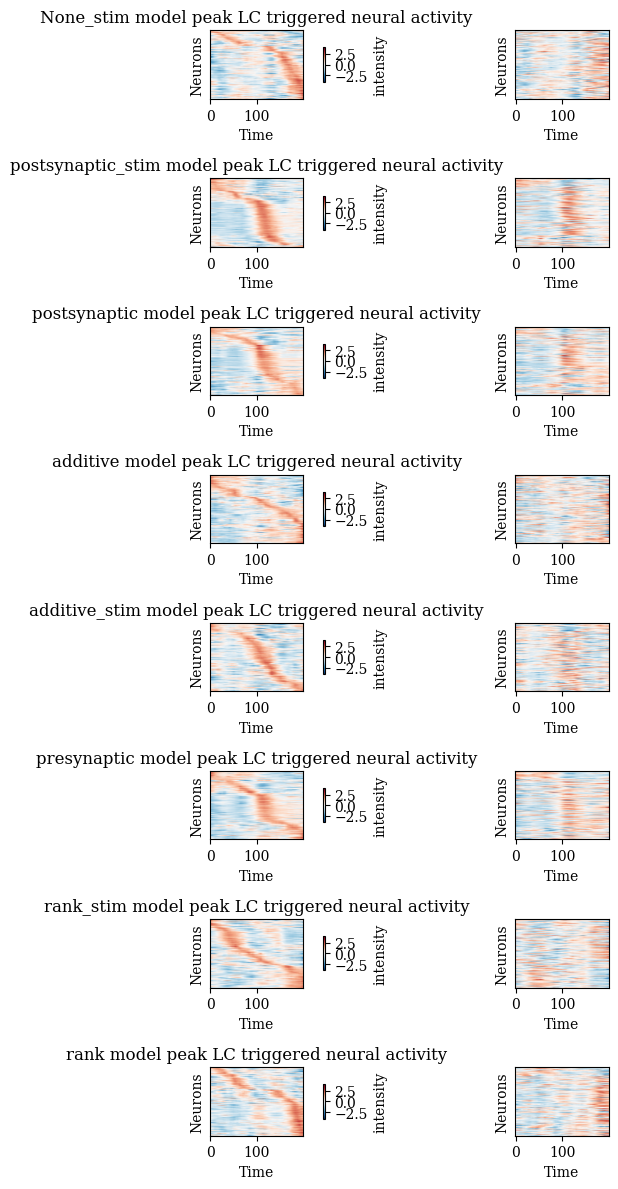

In [23]:
trajs = {}
fig, ax = plt.subplots(len(list(models.keys())), 2, figsize=(8,12))
for i, model in enumerate(models.keys()):
    neuromod = model
    print(neuromod)
    stim = torch.zeros((3, spike_counts_val.shape[1]))
    if 'stim' not in neuromod: stim=None
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim=stim)
    psth_vals, psths, nrpn, ind_1 = compute_LC_trig_activity(trajs[neuromod].detach(), neuromod_val, dur=200)
    psths_resorted = psth_vals[np.argsort(ind_test)]
    psths_resorted = (psths_resorted - psths_resorted.mean(axis=1, keepdims=True)) / psths_resorted.std(axis=1, keepdims=True)
    print(((psths_resorted - psths_val)**2).sum())
    mappable1 = ax[i, 0].imshow(psths, cmap='RdBu_r', vmin=-4, vmax=4)
    mappable2 = ax[i, 1].imshow(psths_resorted, cmap='RdBu_r', vmin=-4, vmax=4)

    ax[i, 0].set_yticks([])
    ax[i, 0].set_yticklabels([])
    ax[i, 0].set_ylabel('Neurons')
    ax[i, 0].set_xlabel('Time')

    ax[i, 1].set_yticks([])
    ax[i, 1].set_yticklabels([])
    ax[i, 1].set_ylabel('Neurons')
    ax[i, 1].set_xlabel('Time')

    fig.colorbar(mappable1, label='intensity', shrink=0.5)
    ax[i, 0].set_title(f'{neuromod} model peak LC triggered neural activity')
plt.tight_layout()

In [ ]:
plt.plot(nrpn)

In [30]:
from scipy.special import softmax
# plt.rcParams['font.family'] = 'DeJavu Serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
cross_corr_traces = {}

for model in models.keys():
    t_start, t_end = t_start_post_trial - 300, t_start_post_trial
    spike_counts_val, neuromod_val, _, = get_block(spike_counts, neuromod_activity, t_start, t_end)
    cross_corr_test = compute_population_cross_corr(spike_counts_val, neuromod_val)
    cross_corr_traces['test'] = cross_corr_test
    kl_divs = []
    
    neuromod = model[0].split('_')[0]
    p_test = softmax(cross_corr_test, axis=1)
    
    for _ in range(5):
        traj = get_trajectory(t_start, t_end, models[model], neuromod)    
        cross_corr_traj = compute_population_cross_corr(traj.detach(), neuromod_val)
        cross_corr_traces[neuromod] = cross_corr_traj 
        p_gen = softmax(cross_corr_traj, axis=1)
        for i in range(p_test.shape[0]):
            kl_div = kl_divergence(p_test[i], p_gen[i])
            kl_divs.append(kl_div)
    print(neuromod, np.array(kl_divs).mean(), np.array(kl_divs).std())
    # fig, ax = plt.subplots(20, 2)
    # for i in range(20):
    #     ax[i, 0].plot(cross_corr_test[i])
    #     ax[i, 1].plot(cross_corr_traj[i])

NameError: name 'compute_population_cross_corr' is not defined

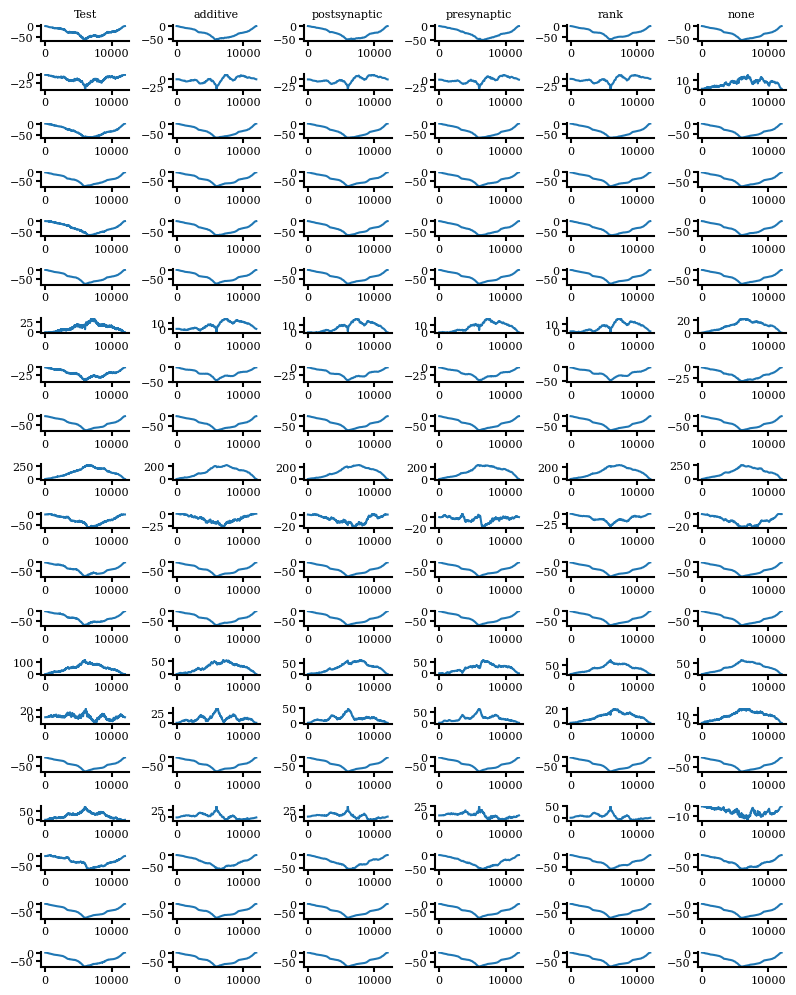

In [55]:
fig, ax = plt.subplots(20, 6, figsize=(8, 10))
for i in range(20):
    if i == 0:
        ax[i, 0].set_title('Test')
        ax[i, 1].set_title('additive')
        ax[i, 2].set_title('postsynaptic')
        ax[i, 3].set_title('presynaptic')
        ax[i, 4].set_title('rank')
        ax[i, 5].set_title('none')
        
        
    ax[i, 0].plot(cross_corr_traces['test'][i])
    ax[i, 1].plot(cross_corr_traces['additive'][i])
    ax[i, 2].plot(cross_corr_traces['postsynaptic'][i])
    ax[i, 3].plot(cross_corr_traces['presynaptic'][i])
    ax[i, 4].plot(cross_corr_traces['rank'][i])
    ax[i, 5].plot(cross_corr_traces['None'][i])
    
plt.tight_layout()
fig.savefig('../../figures/cross_corr_neuromod.png')

In [25]:
def plot_traces(neurons, traj, spike_counts_block, neuromod_block, neuromod):
    fig, ax = plt.subplots(len(neurons) + 1, 1, figsize=(10, 14))

    for i, neuron in enumerate(neurons): 
        if i == 0:
            ax[i].plot(spike_counts_block[neuron], label='Test')
            ax[i].plot(traj[neuron].detach(), label='Gen')
        else:
            ax[i].plot(spike_counts_block[neuron])
            ax[i].plot(traj[neuron].detach())
        ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')
    handles, labels = [], []
    for axis in ax:  # Loop through all axes
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax[-1].plot(neuromod_block)
    ax[-1].set_title('Norepinephrine')
    plt.tight_layout()
    plt.title(f'{neuromod} Traces')
    fig.legend(handles, labels)
    # fig.savefig('presynaptic.png')

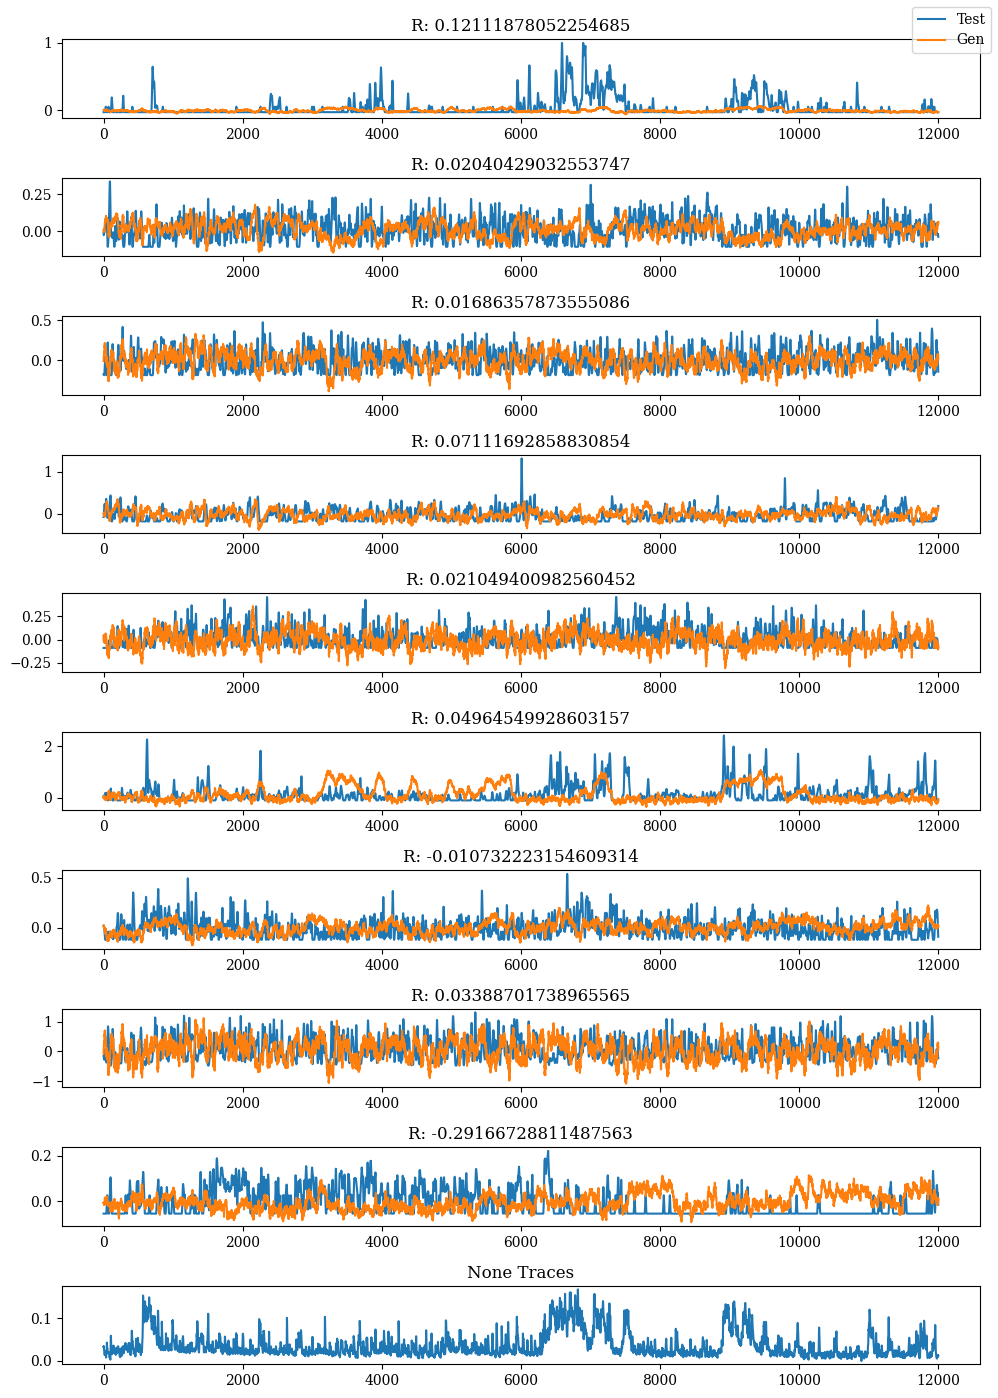

In [26]:
neurons = [132, 50, 15, 117, 78, 144, 80, 17, 90]
plot_traces(neurons, trajs['None_stim'], spike_counts_val, neuromod_val, 'None')

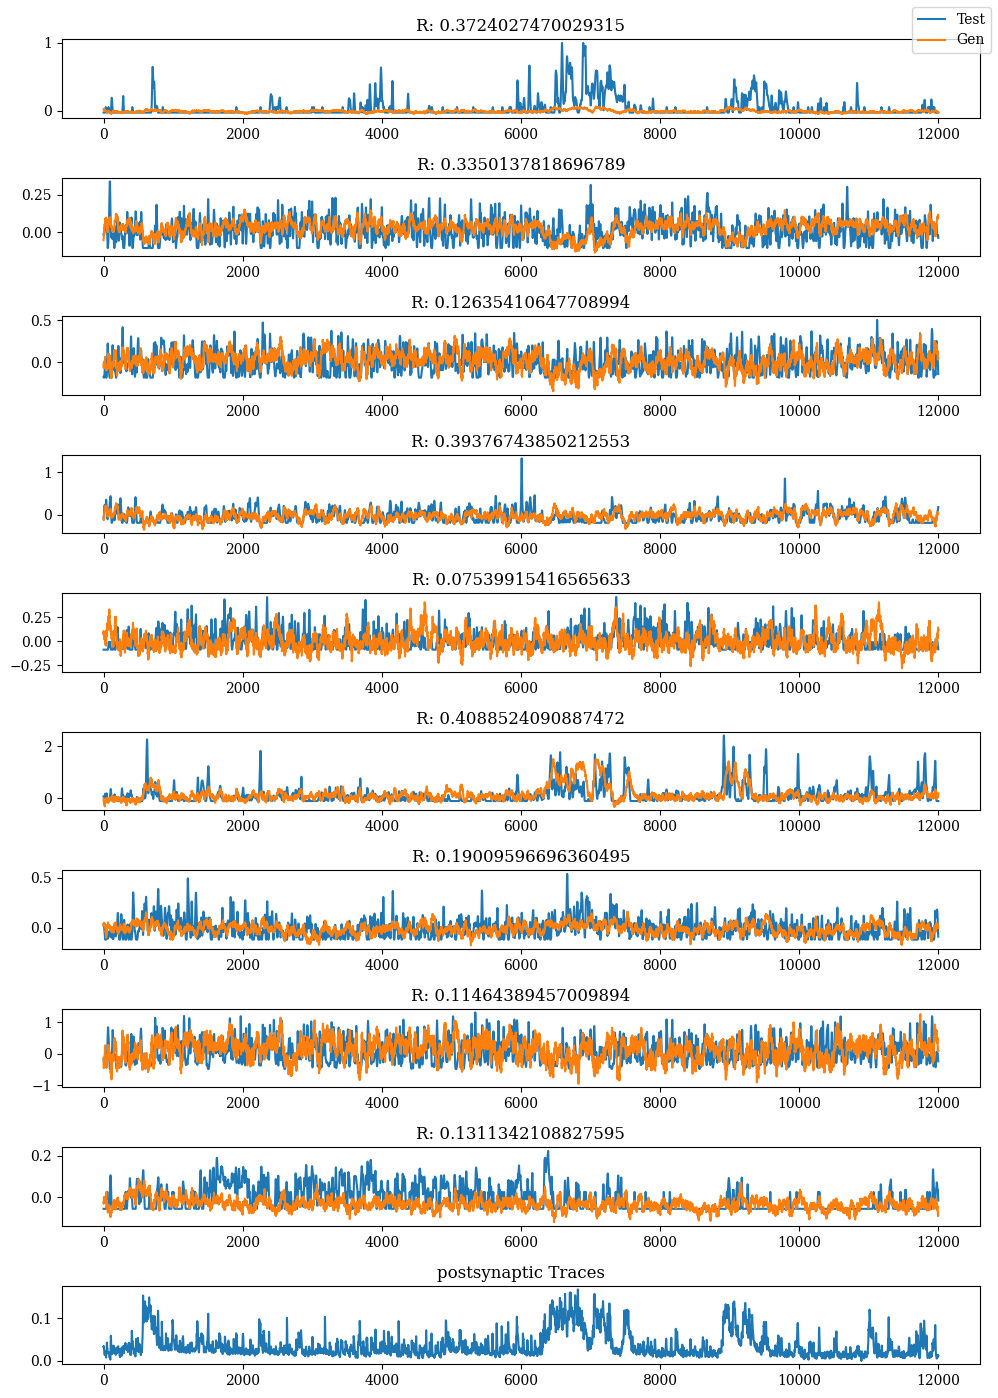

In [27]:
# neurons = [172, 50, 15, 167, 30, 110]
plot_traces(neurons, trajs['postsynaptic_stim'], spike_counts_val, neuromod_val, 'postsynaptic')

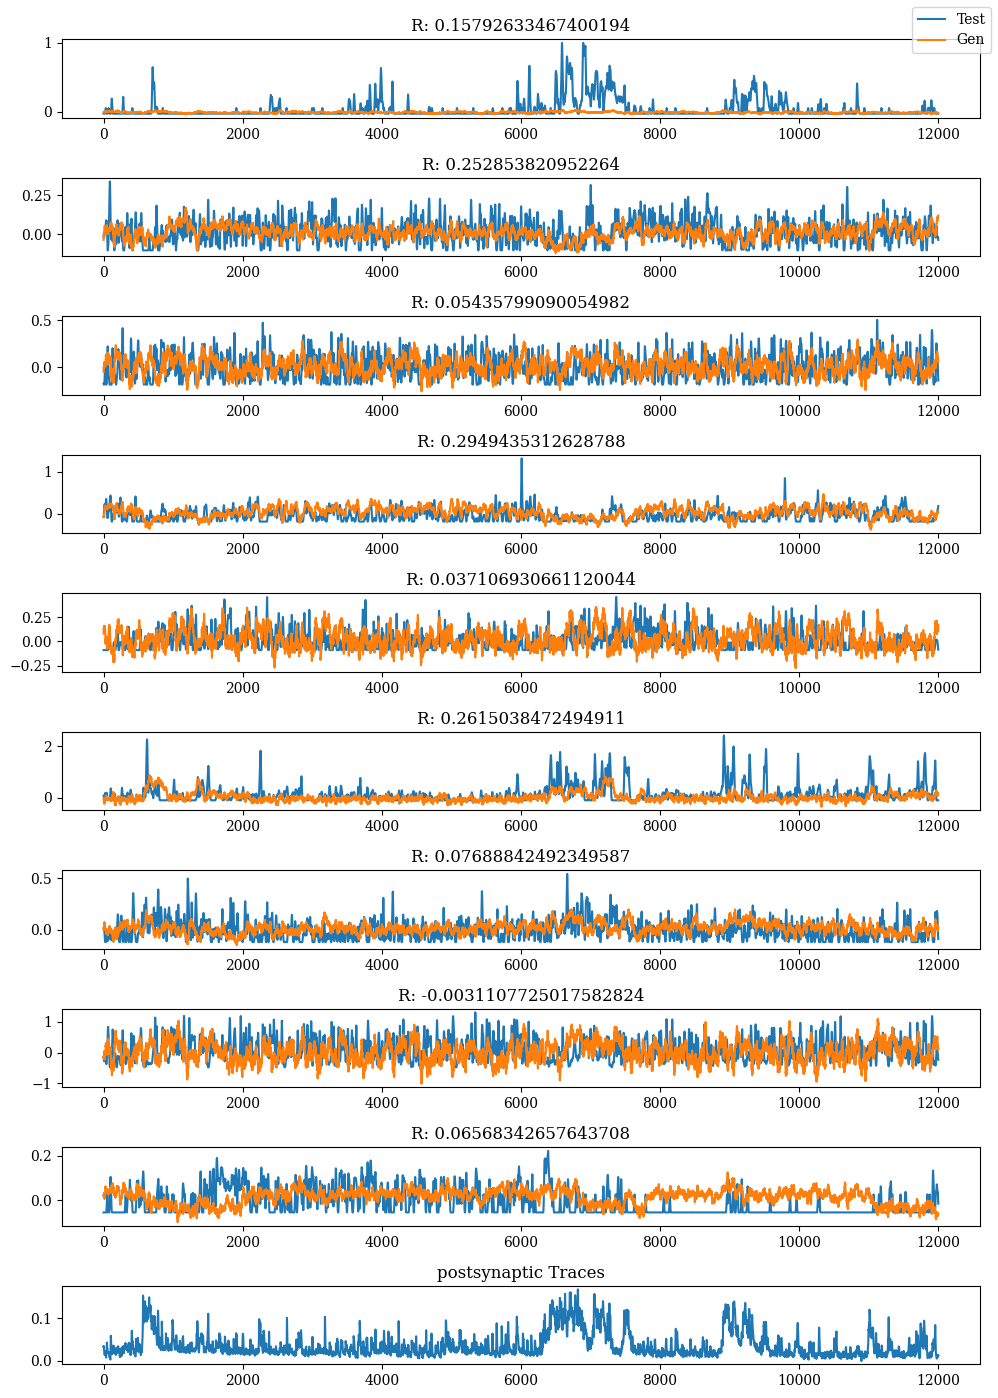

In [28]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'postsynaptic')

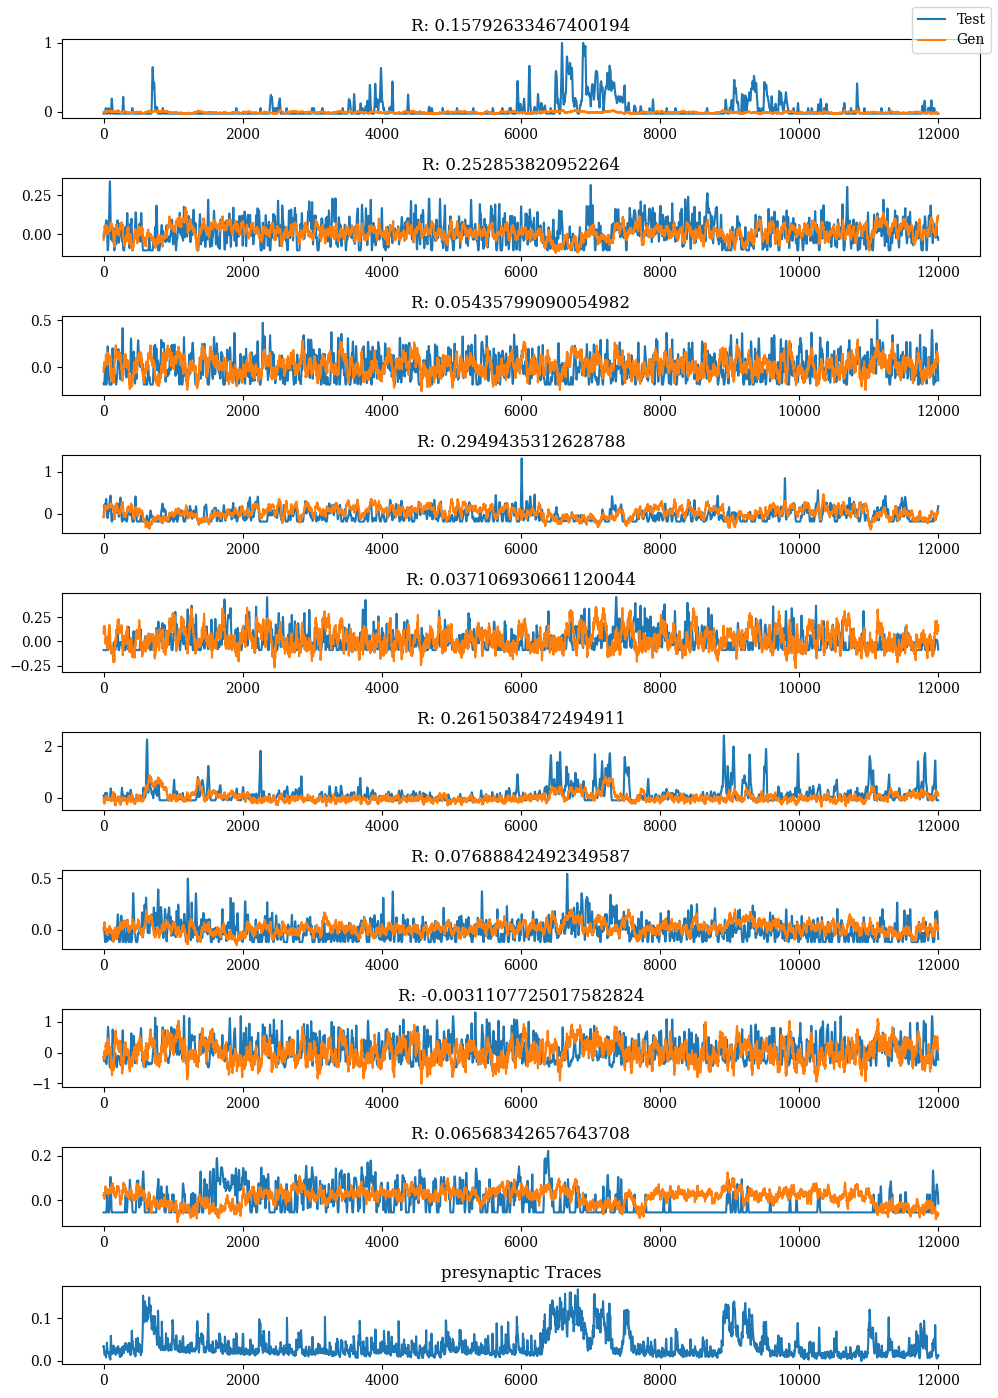

In [29]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'presynaptic')

/tmp/ipykernel_498200/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


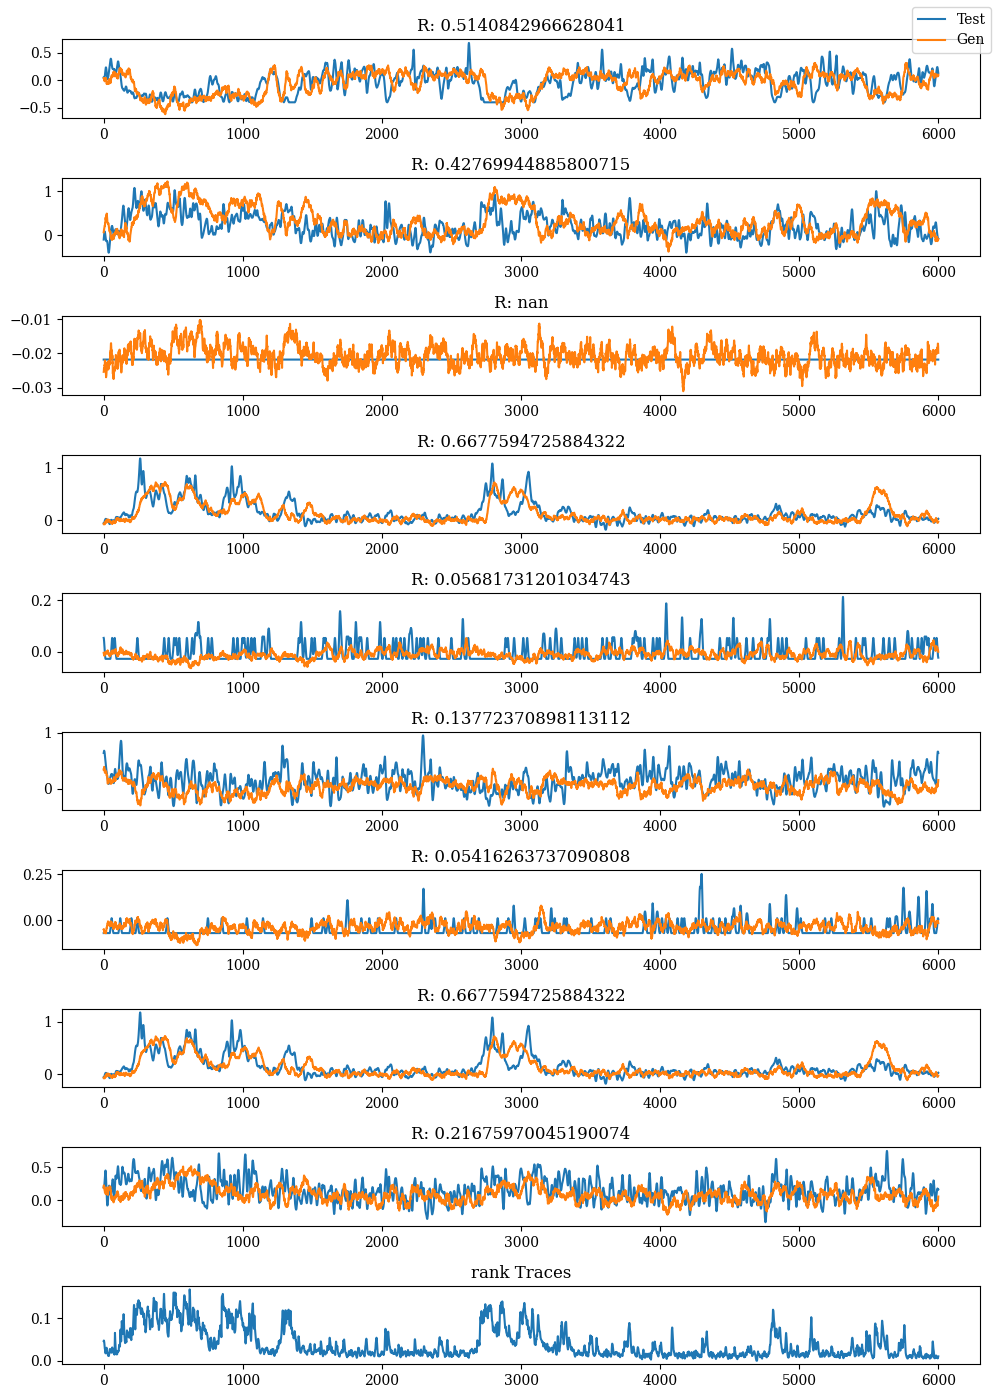

In [37]:
plot_traces(neurons, trajs['rank'], spike_counts_val, neuromod_val, 'rank')

### Visualize and compare pairwise correlations

<Axes: >

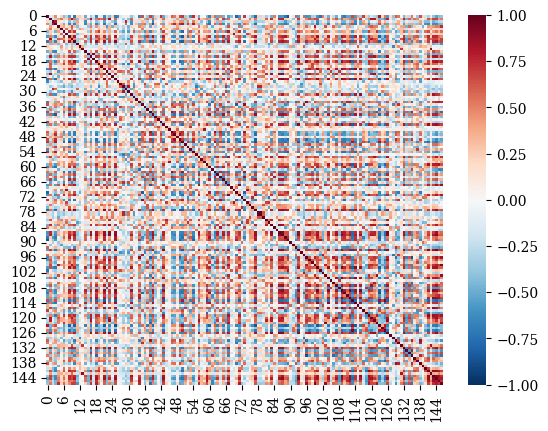

In [69]:
import seaborn as sns

corr_none = calculate_correlation(trajs['None_stim'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
sns.heatmap(corr_none, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

/network/iss/home/kaleab.belay/.conda/envs/py3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/network/iss/home/kaleab.belay/.conda/envs/py3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Text(0.5, 1.0, 'R = 0.5674807597811391')

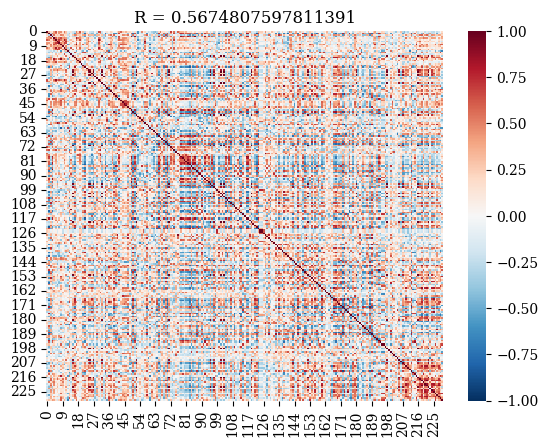

In [51]:
# compute and plot cross-correlation of all neurons in additive model
corr_add = calculate_correlation(trajs['additive'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
corr_add = np.nan_to_num(corr_add)
corr_test = np.nan_to_num(corr_test)
sns.heatmap(corr_add, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
r = pearsonr(corr_add.flatten(), corr_test.flatten())
plt.title(f'R = {r[0]}')
# plt.savefig('autocorr_additive.png')

<Axes: >

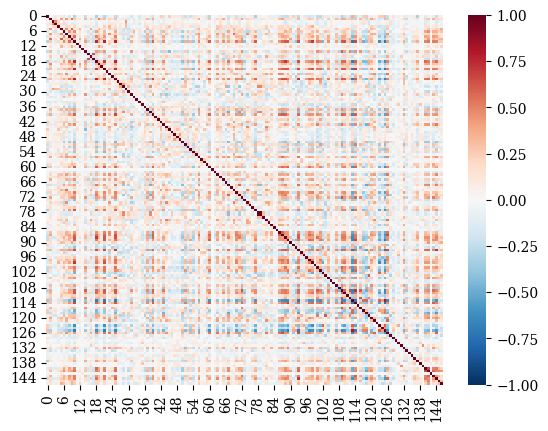

In [70]:
sns.heatmap(corr_test, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
# plt.savefig('autocorr_test.png')

In [71]:
corr_none = np.nan_to_num(corr_none)
corr_test = np.nan_to_num(corr_test)

r = pearsonr(corr_none.flatten(), corr_test.flatten())
mse_none = ((corr_none.flatten() - corr_test.flatten()) ** 2).sum() / corr_none.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.7339213538440522, pvalue=0.0) 0.08474953833120982


In [54]:
r = pearsonr(corr_add.flatten(), corr_test.flatten())
mse_add_1= ((corr_add.flatten() - corr_test.flatten()) ** 2).sum() / corr_add.flatten().shape[0] 
print(r, mse_add_1)

PearsonRResult(statistic=0.5674807597811391, pvalue=0.0) 0.08322720097634123


<Axes: >

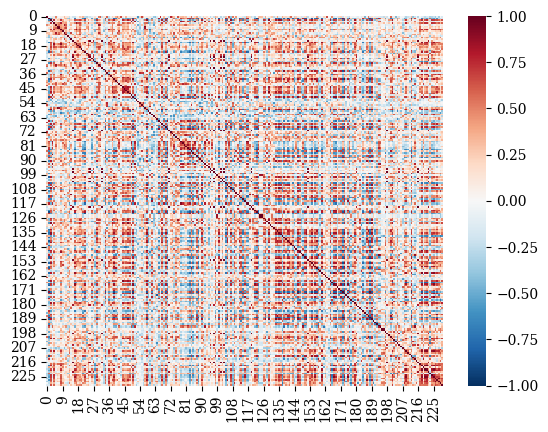

In [55]:
corr_post = calculate_correlation(trajs['postsynaptic'].detach().T.numpy())
sns.heatmap(corr_post, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [56]:
corr_post = np.nan_to_num(corr_post)
corr_test = np.nan_to_num(corr_test)

r = pearsonr(corr_post.flatten(), corr_test.flatten())
mse_post = ((corr_post.flatten() - corr_test.flatten()) ** 2).sum() / corr_post.flatten().shape[0] 
print(r, mse_post)

PearsonRResult(statistic=0.6738827269209577, pvalue=0.0) 0.08072325372988909


<Axes: >

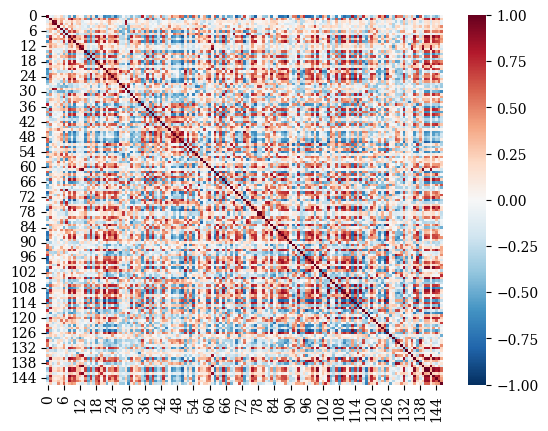

In [44]:
corr_pre = calculate_correlation(trajs['presynaptic'].detach().T.numpy())
sns.heatmap(corr_pre, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [45]:
r = pearsonr(corr_pre.flatten(), corr_test.flatten())
mse_none = ((corr_pre.flatten() - corr_test.flatten()) ** 2).sum() / corr_pre.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.763441973016564, pvalue=0.0) 0.07538307685282473


<Axes: >

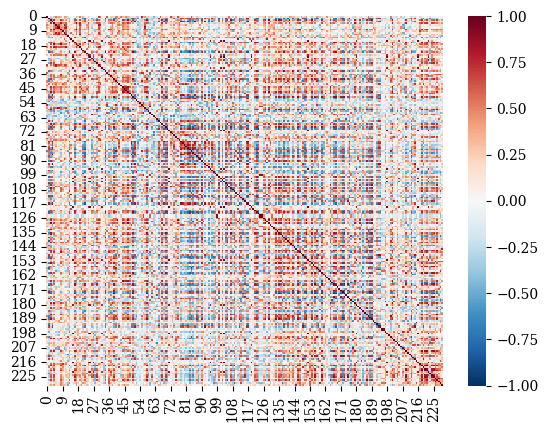

In [59]:
corr_rank = calculate_correlation(trajs['rank'].detach().T.numpy())
sns.heatmap(corr_rank, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [60]:
r = pearsonr(corr_rank.flatten(), corr_test.flatten())
mse_none = ((corr_rank.flatten() - corr_test.flatten()) ** 2).sum() / corr_rank.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.6513136305113488, pvalue=0.0) 0.07924732050857576


### Compare the autocorrelograms

In [37]:
from scipy.special import rel_entr
def kl_divergence(p, q):
    """
    Compute the Kullback-Leibler (KL) divergence between two autocorrelograms.
    
    Parameters:
    p (numpy array): First autocorrelogram (distribution)
    q (numpy array): Second autocorrelogram (distribution)
    
    Returns:
    float: KL divergence
    """
    # Normalize to form probability distributions
    p = p / np.sum(p)
    q = q / np.sum(q)

    # Avoid log(0) by replacing zeros with a small value
    eps = 1e-10
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    # Compute KL divergence
    kl_div = np.sum(rel_entr(p, q))
    return kl_div

In [ ]:
from scipy.special import kl_div
fig, ax = plt.subplots(9, 6)
neurons = [172, 50, 15, 167, 30, 167, 34, 53, 180, 100]
autocorr_kl_divs_none = []
autocorr_kl_divs_add = []
autocorr_kl_divs_post = []
autocorr_kl_divs_pre = []
autocorr_kl_divs_rank = []

autocorr_mses_none = []
autocorr_mses_add = []
autocorr_mses_post = []
autocorr_mses_pre = []
autocorr_mses_rank = []

fig_count = 0
for i in range(spike_counts.shape[0]):
    cross_corr_gen_none = np.correlate(trajs['None'][i].detach(), trajs['None'][i].detach(), mode='full')
    cross_corr_gen_add = np.correlate(trajs['additive'][i].detach(), trajs['additive'][i].detach(), mode='full')
    cross_corr_gen_pre = np.correlate(trajs['postsynaptic'][i].detach(), trajs['postsynaptic'][i].detach(), mode='full')
    cross_corr_gen_post = np.correlate(trajs['presynaptic'][i].detach(), trajs['presynaptic'][i].detach(), mode='full')
    cross_corr_gen_rank = np.correlate(trajs['rank'][i].detach(), trajs['rank'][i].detach(), mode='full')
    
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')

    cross_corr_test /= cross_corr_test.max()

    cross_corr_gen_none /= cross_corr_gen_none.max()
    cross_corr_gen_add /= cross_corr_gen_add.max()
    cross_corr_gen_pre /= cross_corr_gen_pre.max()
    cross_corr_gen_post /= cross_corr_gen_post.max()
    cross_corr_gen_rank /= cross_corr_gen_rank.max()
    
    mse_none = np.mean((cross_corr_gen_none - cross_corr_test) ** 2)
    mse_add = np.mean((cross_corr_gen_add - cross_corr_test) ** 2)
    mse_post = np.mean((cross_corr_gen_post - cross_corr_test) ** 2)
    mse_pre = np.mean((cross_corr_gen_pre - cross_corr_test) ** 2)
    mse_rank = np.mean((cross_corr_gen_rank - cross_corr_test) ** 2)

    autocorr_mses_none.append(mse_none)
    autocorr_mses_add.append(mse_add)
    autocorr_mses_post.append(mse_post)
    autocorr_mses_pre.append(mse_pre)
    autocorr_mses_rank.append(mse_rank)

    kl_divg_none = kl_divergence(cross_corr_gen_none, cross_corr_test)
    kl_divg_add = kl_divergence(cross_corr_gen_add, cross_corr_test)
    kl_divg_post = kl_divergence(cross_corr_gen_post, cross_corr_test)
    kl_divg_pre = kl_divergence(cross_corr_gen_pre, cross_corr_test)
    kl_divg_rank = kl_divergence(cross_corr_gen_rank, cross_corr_test)
    
    autocorr_kl_divs_none.append(kl_divg_none)
    autocorr_kl_divs_add.append(kl_divg_add)
    autocorr_kl_divs_post.append(kl_divg_post)
    autocorr_kl_divs_pre.append(kl_divg_pre)
    autocorr_kl_divs_rank.append(kl_divg_rank)

    if i in neurons:
        if fig_count == 0:
            ax[fig_count, 0].set_title('Test')
            ax[fig_count, 1].set_title('None')
            ax[fig_count, 2].set_title('Additive')
            ax[fig_count, 3].set_title('Postsynaptic')
            ax[fig_count, 4].set_title('Presynaptic')
            ax[fig_count, 5].set_title('Rank')

        ax[fig_count, 0].plot(cross_corr_test)
        ax[fig_count, 1].plot(cross_corr_gen_none)
        ax[fig_count, 2].plot(cross_corr_gen_add)
        ax[fig_count, 3].plot(cross_corr_gen_post)
        ax[fig_count, 4].plot(cross_corr_gen_pre)
        ax[fig_count, 5].plot(cross_corr_gen_rank)
        fig_count += 1

### Pearson correlation of neurons across models

### R through time

In [211]:
from tqdm import tqdm
# select a 5 minute window in the validation set
t_start, t_end = t_start_post_trial - 120, t_start_post_trial 
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
# for all models get trajectories in that window 
trajs = {"None": [], "presynaptic": [], "postsynaptic": [], "rank": []}
num_trajs = 1
for model in models.keys():
    if model == 'additive': continue 
    trajs[model] = get_trajectory(t_start, t_end, models[model], model, -1)

wind_size = 1000
mini_block_size = 20
r_vals = {"None": [], "presynaptic": [], "postsynaptic": [], "rank": []}
pbar = tqdm()
for model in models.keys():
    print(model)
    if model == 'additive': continue
    block_start, block_end = 0, wind_size
    while block_end < trajs[model].shape[1]:
        r_block = []
        i, j = block_start, block_start + mini_block_size
        while j < block_end:
            r_neurons = []
            for k in range(trajs[model].shape[0]):
                r_neurons.append(pearsonr(trajs[model][k, i:j].detach().flatten(), spike_counts_val[k, i:j].flatten())[0])
            r_block.append(np.nanmean(r_neurons))
            i = j + 1
            j += mini_block_size
        r_vals[model].append(r_block)
        block_start, block_end = block_start + wind_size, block_end + wind_size
        pbar.update(1)

no input
no input
no input
no input



8it [02:32, 19.05s/it]
/tmp/ipykernel_255501/943497893.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_neurons.append(pearsonr(trajs[model][k, i:j].detach().flatten(), spike_counts_val[k, i:j].flatten())[0])


None



 [00:04,  4.57s/it]
 [00:09,  4.61s/it]

additive
postsynaptic



 [00:13,  4.59s/it]
 [00:18,  4.61s/it]

presynaptic



 [00:22,  4.60s/it]
 [00:27,  4.62s/it]

rank



 [00:32,  4.61s/it]
 [00:36,  4.62s/it]

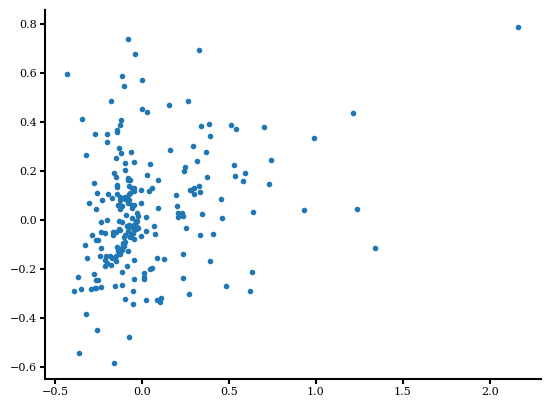

In [134]:
plt.scatter(spike_counts_val[:, i:i + 1],trajs[model][:, i:i+1].flatten().detach().numpy())

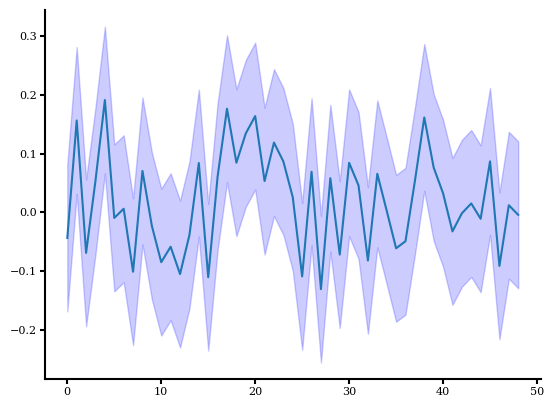

In [212]:
plt.plot(np.array(r_vals['None']).mean(axis=0))
std_values = np.array(r_vals['None']).std()
x = np.arange(0, len(r_vals['None'][0]))
plt.fill_between(
    x,
    np.array(r_vals['None']).mean(axis=0) - std_values,
    np.array(r_vals['None']).mean(axis=0) + std_values,
    color='blue',
    alpha=0.2,
    label='±1 STD'
)
# plt.savefig('r_none.png')

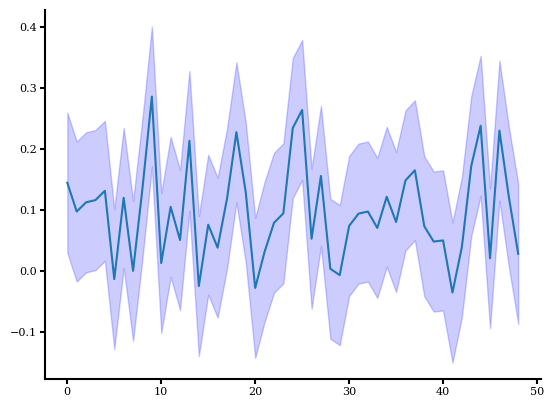

In [213]:
plt.plot(np.array(r_vals['presynaptic']).mean(axis=0))
std_values = np.array(r_vals['presynaptic']).std()
x = np.arange(0, len(r_vals['presynaptic'][0]))
plt.fill_between(
    x,
    np.array(r_vals['presynaptic']).mean(axis=0) - std_values,
    np.array(r_vals['presynaptic']).mean(axis=0) + std_values,
    color='blue',
    alpha=0.2,
    label='±1 STD'
)
# plt.savefig('r_presynaptic.png')

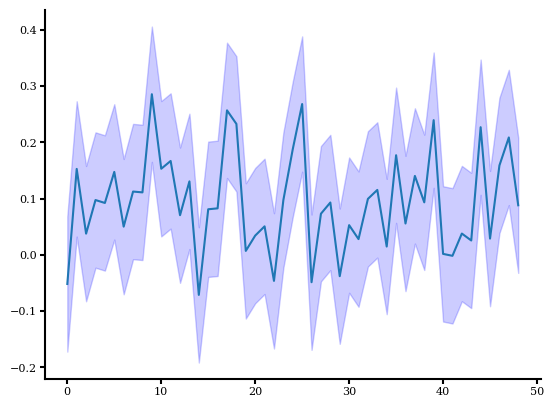

In [214]:
plt.plot(np.array(r_vals['postsynaptic']).mean(axis=0))
std_values = np.array(r_vals['postsynaptic']).std()
x = np.arange(0, len(r_vals['postsynaptic'][0]))
plt.fill_between(
    x,
    np.array(r_vals['postsynaptic']).mean(axis=0) - std_values,
    np.array(r_vals['postsynaptic']).mean(axis=0) + std_values,
    color='blue',
    alpha=0.2,
    label='±1 STD'
)
plt.savefig('r_postsynaptic.png')

In [ ]:
num_trajs = 20
t_start, t_end = t_start_post_trial - 300, t_start_post_trial 
spike_counts_val, neuromod_val, = get_block(spike_counts, neuromod_activity, t_start, t_end)

r_model = {}

for model in models.keys():
    if model == 'additive': continue 
    # compute the r 
    r_vals = []
    for i in range(spike_counts_val.shape[0]):
        r_neuron = []
        for _ in range(num_trajs):
            traj = get_trajectory(t_start, t_end, models[model], model)         
            r = pearsonr(spike_counts_val[i], traj[i].detach())[0]
            r_neuron.append(r)
        r_vals.append(np.array(r_neuron).mean())
    r_model[model] = r_vals
    print(model, np.array(r_vals).mean())

no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
n

/tmp/ipykernel_159183/4243994249.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(spike_counts_val[i], traj[i].detach())[0]


no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
no input
n

In [10]:
from evaluation.kl_Gauss import calc_kl_from_data
def compute_KL_divergence(pred_trajectories, x):
    """
    Computes the KL divergence over simulated and actual trajectories 
    
    Args: 
        pred_trajectories (torch.Tensor); n_trials x dim_x x time_steps: predicted trajectories 
        x (torch.Tensor): n_trials x dim_x x time_steps: actual neural activity 

    Returns: 
        kl_div: Estimated kernel divergence  
    """
    # reshape pred_trajectories and x 
    n_trials, trial_dur = pred_trajectories.shape[0], pred_trajectories.shape[2]
    pred_trajectories_ = pred_trajectories.permute((0, 2, 1)).reshape(n_trials*trial_dur, -1)
    x_ = x.permute((0, 2, 1)).reshape(n_trials*trial_dur, -1)
    kl_div = calc_kl_from_data(pred_trajectories_, x_)
    return kl_div.item()

In [11]:
from scipy.optimize import linear_sum_assignment
def calc_wasserstein_mc(mu_inf, mu_gen, scale, n_samples=200):
    """
    Estimate the 2-Wasserstein distance between two GMMs (mu_inf, mu_gen)
    via Monte Carlo sampling + the Hungarian algorithm for Optimal Transport.

    mu_inf, mu_gen: (T, dim_x) => each row is a GMM component mean
    scale: float or tensor => std for diagonal covariance
    n_samples: how many points to sample from each distribution
    """
    # 1) Draw samples from each GMM
    # z_inf = sample_from_gmm(mu_inf, scale, n_samples)  # shape (n_samples, dim_x)
    # z_gen = sample_from_gmm(mu_gen, scale, n_samples)  # shape (n_samples, dim_x)
    z_inf = mu_inf[:n_samples, :]
    z_gen = mu_gen[:n_samples, :]
    
    # 3) Compute the cost matrix: here we use squared Euclidean distance
    #    for the 2-Wasserstein (W2). cost[i, j] = ||z_inf[i] - z_gen[j]||^2
    diff = z_inf[:, None, :] - z_gen[None, :, :]
    cost_matrix = np.sum(diff**2, axis=2)  # shape (n_samples, n_samples)
    
    # 4) Solve the OT problem for uniform distributions (each sample is weight = 1/n_samples)
    #    linear_sum_assignment finds a minimum-cost one-to-one matching.
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # 5) The sum of the matched distances is the total transport cost.
    #    For W2, we want the square root of the average squared distance:
    #    W2^2 = (1/n) * sum(cost_matrix[row_ind, col_ind])
    #    => W2 = sqrt(W2^2)
    w2_squared = cost_matrix[row_ind, col_ind].mean()
    w2_distance = np.sqrt(w2_squared)
    
    return w2_distance

def compute_stats_new(models, block, num_trajs=20, num_samples=3000):
    if block == 'validation':
        t_start, t_end = t_start_post_trial - 300, t_start_post_trial 
        return compute_stats(models, t_start, t_end, block, num_trajs, num_samples)
    elif block == 'airpuff' or block == 'white_noise':
        # concatenate all airpuff test trajectories 
        block_range = (9, len(seq_periods)) if block == 'airpuff' else (1, 9)
        model_kl_divs = {}
        model_pshs = {}
        model_mres = {}
        model_was_dists = {}
        
        for j, model in enumerate(models.keys()):
            pairwise_corrs, kl_divs, pshs, mres, cross_corrs, was_dists = [], [], [], [], [], []
            for k in range(num_trajs):
                trajs = []
                spike_counts_val = []    
                print(model)
                for i in range(block_range[0], block_range[1]):
                    t_start, t_end = seq_periods[i]
                    spike_counts_trial = x_train[:, t_start:t_end]
                    spike_counts_val.append(spike_counts_trial)
                    neuromod_val = s_train[t_start:t_end]
                    stim = torch.from_numpy(stim_arr_train[:, t_start:t_end]).to(torch.float32)
                    if 'stim' not in model: stim = None 
                    traj_trial = get_trajectory(t_start, t_end, models[model], model, stim=stim, use_index=True)
                    trajs.append(traj_trial.detach().numpy())
                # compute stats on concatenated trajectories 
                trajs = torch.from_numpy(np.hstack(trajs)).to(torch.float32)
                spike_counts_val = np.hstack(spike_counts_val)
    
                kl_div = compute_KL_divergence(trajs.unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
                was_dist = calc_wasserstein_mc(spike_counts_val.T, trajs.T.detach().numpy(), 1.0, n_samples=num_samples)
                psh = power_spectrum_helling(trajs.unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000)
                mr = mean_rate(trajs.detach().numpy(), spike_counts_val)
                print(f'Sample {k}, KL Div: {kl_div}, Wasserstein: {was_dist}, r: {r}, PSH: {psh}, mean-rate: {mr}')

                pairwise_corrs.append(r)
                kl_divs.append(kl_div)
                was_dists.append(was_dist)
                pshs.append(psh)
                mres.append(mr)
            print(model)
            print(f'KL Div: {np.array(kl_divs).mean()} std: {np.array(kl_divs).std()}')
            print(f'Wasserstein dist: {np.array(was_dists).mean()} std: {np.array(was_dists).std()}')
            print(f'Mean rate error: {np.array(mres).mean()} std: {np.array(mres).std()}')
            print(f'PSH: {np.array(pshs).mean()} std: {np.array(pshs).std()}')
            print(f'Autocorr: {np.array(pairwise_corrs).mean()} std: {np.array(pairwise_corrs).std()}')
            model_kl_divs[model] = kl_divs
            model_pshs[model] = pshs
            model_was_dists[model] = was_dists
            model_mres[model] = mres
        return model_kl_divs, model_pshs, model_was_dists, model_mres 
            
def compute_stats(t_start, t_end, models, block, num_trajs=20, num_samples=3000):
    spike_counts_val, neuromod_val, = get_block(spike_counts, neuromod_activity, t_start, t_end)
    
    if block == 'validation': 
        stim = torch.zeros((3, spike_counts_val.shape[1]))
    elif block == 'airpuff': 
        stim = torch.from_numpy(stim_arr_airpuff).to(torch.float32)
    elif block == 'white_noise':
        stim = torch.from_numpy(stim_arr_white_noise).to(torch.float32)
    elif block == 'airpuff_2':
        stim = torch.from_numpy(stim_arr_airpuff_2).to(torch.float32)
    else:
        stim = torch.from_numpy(stim_arr_white_noise_2).to(torch.float32)
    model_kl_divs, model_mres, model_was_dists = {}, {}, {}
    for i, model in enumerate(models.keys()):
        neuromod = model
        pairwise_corrs, kl_divs, pshs, mres, cross_corrs, was_dists = [], [], [], [], [], []
        print(neuromod)
        for num_traj in range(num_trajs):
            corr_test = calculate_correlation(spike_counts_val.T) 
            if 'stim' not in neuromod:
                traj = get_trajectory(t_start, t_end, models[model], neuromod, None)
            else:
                traj = get_trajectory(t_start, t_end, models[model], neuromod, stim)
                
            corr_neuromod = calculate_correlation(traj.detach().T.numpy())
            corr_test = np.nan_to_num(corr_test)
            corr_neuromod = np.nan_to_num(corr_neuromod)
            
            r = pearsonr(corr_neuromod.flatten(), corr_test.flatten())[0]
            kl_div = compute_KL_divergence(traj.unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
            was_dist = calc_wasserstein_mc(spike_counts_val.T, traj.T.detach().numpy(), 1.0, n_samples=num_samples)
            psh = power_spectrum_helling(traj.unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000) 
            mr = mean_rate(traj.detach().numpy(), spike_counts_val)
            print(f'Sample {num_traj}, KL Div: {kl_div}, Wasserstein: {was_dist}, r: {r}, PSH: {psh}, mean-rate: {mr}')
            
            pairwise_corrs.append(r)
            kl_divs.append(kl_div)
            was_dists.append(was_dist)
            pshs.append(psh)
            mres.append(mr)
            
        print(neuromod)
        print(f'KL Div: {np.array(kl_divs).mean()} std: {np.array(kl_divs).std()}')
        print(f'Wasserstein dist: {np.array(was_dists).mean()} std: {np.array(was_dists).std()}')
        print(f'Mean rate error: {np.array(mres).mean()} std: {np.array(mres).std()}')
        print(f'PSH: {np.array(pshs).mean()} std: {np.array(pshs).std()}')
        print(f'Autocorr: {np.array(pairwise_corrs).mean()} std: {np.array(pairwise_corrs).std()}')
        model_kl_divs[model] = kl_divs
        model_pshs[model] = pshs 
        model_was_dists[model] = was_dists 
        model_mres[model] = mres 
    return model_kl_divs, model_pshs, model_was_dists, model_mres

## Evaluate state-space metrics

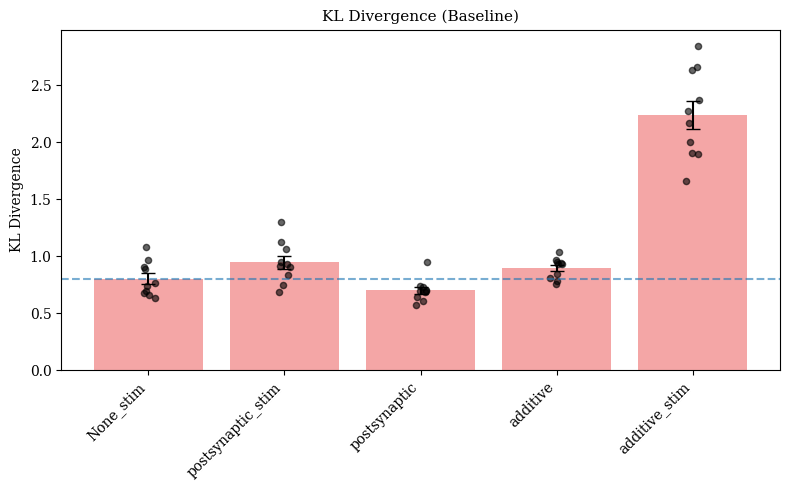

In [458]:
def plot_bar_scatter_sem(ax, data_dict, title, y_label='KL Divergence'):
    """
    Plots a bar chart (mean ± SEM) for each key in data_dict,
    overlaid with scatter points for the individual data.
    
    Additionally, draws arrows from each scatter point in bar j
    to the *corresponding* scatter point in bar j+1 (for i-th data index).
    
    Requirements:
      - All lists in data_dict have the same length.
      - The dictionary has at least 2 keys (so there's something to connect).
    """
    keys = list(data_dict.keys())  # e.g. ["None", "Postsynaptic", ...]
    n_keys = len(keys)
    
    # 1) Compute mean & SEM for each condition
    #    (replace with std if you want standard deviation)
    means = []
    sems  = []
    for k in keys:
        vals = data_dict[k]
        m    = np.mean(vals)
        std  = np.std(vals, ddof=1)
        n    = len(vals)
        sem  = std / np.sqrt(n)   # standard error of the mean
        means.append(m)
        sems.append(sem)
    
    x_pos = np.arange(n_keys)  # x-locations of each bar
    
    # 2) Plot the bars with error bars (SEM)
    ax.bar(x_pos, means, yerr=sems, capsize=5, alpha=0.7, color='lightcoral')
    
    # 3) Plot scatter points & keep track of their (x,y) positions
    #    We store them so we can draw arrows between corresponding points.
    scatter_positions = [[] for _ in range(n_keys)]
    # scatter_positions[j] will hold (x_i, y_i) for each data i in the j-th bar
    
    for j, k in enumerate(keys):
        values = data_dict[k]
        n_vals = len(values)
        # random jitter in x so points don't overlap
        x_jitter = np.random.uniform(-0.05, 0.05, size=n_vals)
        for i, val in enumerate(values):
            x_i = x_pos[j] + x_jitter[i]
            y_i = val
            ax.scatter(x_i, y_i, color='black', alpha=0.6, s=20)
            scatter_positions[j].append((x_i, y_i))
    
    # 4) Draw arrows between consecutive bars for each data index
    #    i.e. from scatter_positions[j][i] to scatter_positions[j+1][i]
    #    for j in [0..(n_keys-2)], i in [0..(n_data-1)]
    
    for j in range(n_keys - 1):
        # next bar is j+1
        # assume same number of data points in each list
        n_data = len(scatter_positions[j])
        for i in range(n_data):
            (xA, yA) = scatter_positions[j][i]
            (xB, yB) = scatter_positions[j+1][i]
            
            # draw an arrow from (xA, yA) to (xB, yB)
            ax.annotate(
                "",  # no text
                xy=(xB, yB),
                xytext=(xA, yA),
                arrowprops=dict(
                    arrowstyle="->",
                    alpha=0.3,
                    color="gray",
                    lw=1.0  # line width
                )
            )
    
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_ylabel(y_label)


In [34]:
def evaluate_state_space(state, num_trajs):
    kl_divs, pshs, was_dists, mres = None, None, None, None
    model_types = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'additive']#, 'additive_stim'] 
    for i in range(0, 10):
        models = {}
        for model in model_types:
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk340_{model_name}_rank_20_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk340_{model}_rank_20_seed_{i}')
            models[model] = vae
        
        model_kl_divs, model_pshs, model_was_dists, model_mres = compute_stats_new(models, state, num_trajs=num_trajs)
        if kl_divs is not None: 
            kl_divs = {k: kl_divs[k] + model_kl_divs[k] for k in kl_divs}
            pshs = {k: pshs[k] + model_pshs[k] for k in pshs}
            was_dists = {k: was_dists[k] + model_was_dists[k] for k in was_dists}
            mres = {k: mres[k] + model_mres[k] for k in mres}
        else:
            kl_divs = model_kl_divs
            pshs = model_pshs
            was_dists = model_was_dists
            mres = model_mres
        return kl_divs, pshs, was_dists, mres

In [457]:
kl_divs_baseline, pshs_baseline, was_dists_baseline, mres_baseline = evaluate_state_space('validation', 10)
        

/network/iss/home/kaleab.belay/mnm/train_scripts/recordings/../../vi_rnn/saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 

/network/iss/home/kaleab.belay/.conda/envs/py3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/network/iss/home/kaleab.belay/.conda/envs/py3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


n outliers: 0.0020000000000000018
Sample 0, KL Div: 0.888171374797821, Wasserstein: 2.5409466571874635, r: 0.4750420319525557, PSH: 0.24283832388149562, mean-rate: 87.37708759403226
n outliers: 0.0030000000000000027
Sample 1, KL Div: 0.6606407165527344, Wasserstein: 2.340255177793447, r: 0.5048485735493367, PSH: 0.24040003975346289, mean-rate: 51.993064716449766
n outliers: 0.0017500000000000293
Sample 2, KL Div: 1.084835410118103, Wasserstein: 2.951621488336338, r: 0.4180934220497724, PSH: 0.24204503370196934, mean-rate: 133.57059808698315
n outliers: 0.0022499999999999742
Sample 3, KL Div: 0.6791056394577026, Wasserstein: 2.5802902474570435, r: 0.4785960156679843, PSH: 0.2430336324136578, mean-rate: 64.6382629299644
n outliers: 0.0022499999999999742
Sample 4, KL Div: 0.9050698280334473, Wasserstein: 2.462256263572095, r: 0.4904758008428449, PSH: 0.2438800665480931, mean-rate: 79.94278878987747
n outliers: 0.0022499999999999742
Sample 5, KL Div: 0.7656190395355225, Wasserstein: 2.3973

KeyboardInterrupt: 

In [432]:
kl_divs_white_noise, pshs_white_noise, was_dists_white_noise, mres_white_noise = evaluate_state_space('white_noise', 10)
        

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 

In [ ]:
kl_divs_airpuff, pshs_airpuff, was_dists_airpuff, mres_airpuff = evaluate_state_space('airpuff', 10)

In [ ]:
kl_divs_reward, pshs_reward, was_dists_reward, mres_reward = evaluate_state_space('rewarad', 10)

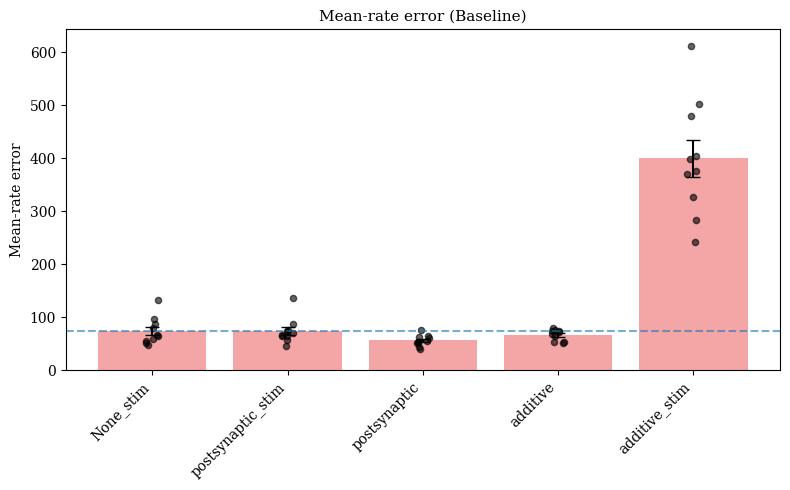

In [460]:
fig, ax = plt.subplots(figsize=(8,5))
plot_bar_scatter_sem(ax, mres_baseline, 'Mean-rate error (Baseline)', y_label='Mean-rate error')
plt.tight_layout()
plt.show()
fig.savefig('mre_baseline.png')

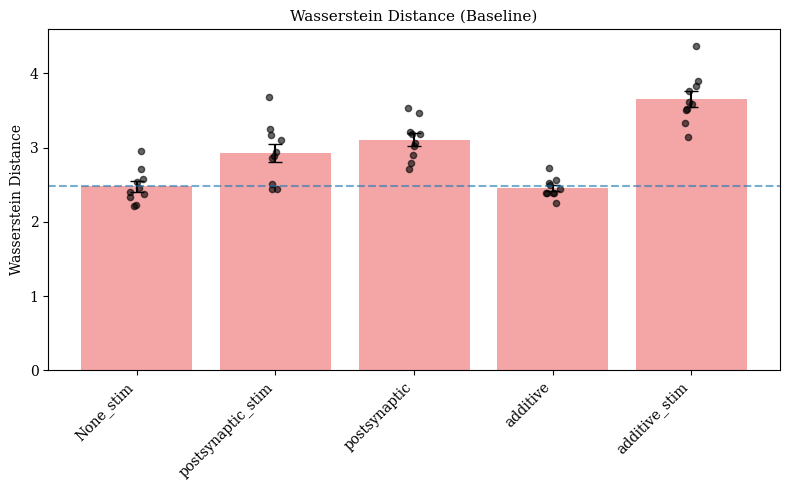

In [459]:
fig, ax = plt.subplots(figsize=(8,5))
plot_bar_scatter_sem(ax, was_dists_baseline, 'Wasserstein Distance (Baseline)', y_label='Wasserstein Distance')
plt.tight_layout()
plt.show()
fig.savefig('wasserstein_baseline.png')

### Perform temporal comparisons during trial blocks

In [37]:
def temporal_eval(block, num_trajs):
    if block == 'white_noise':
        block_range = range(5, 7)
        # block_range = range(6, 8)
    elif block == 'airpuff': 
        block_range = range(12, 15)
        # block_range = range(13, 16)
    else:
        block_range = range(15, len(seq_periods))
        # block_range = range(16, len(seq_periods))
        
    models = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'additive', 'additive_stim'] 
    
    trajs, r_vals, avg_trajs, test_avg_trajs = {}, {}, {}, {}, []

    trajs['test'] = []
    for j in block_range:
        t_start, t_end = seq_periods[j]
        trajs['test'].append(torch.from_numpy(x_train[:, t_start:t_end]))
    
    for model in models:
        for i in range(0, 10):
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk340_{model_name}_rank_20_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk340_{model}_rank_20_seed_{i}')
            
            for j in block_range:
                t_start, t_end = seq_periods[j]
                spike_counts_val = x_train[:, t_start : t_end] 
                if model not in trajs_wn.keys():
                    trajs[model] = []
                    r_vals[model] = [] 
                    avg_trajs_wn[model] = []          
                    
                if 'stim' in model:
                    stim = torch.from_numpy(stim_arr_train[:, t_start : t_end]).to(torch.float32)
                else: stim = None 
                
                # generate 10 trajectories 
                for _ in range(num_trajs):      
                    traj = get_trajectory(t_start, t_end, vae, model, stim, use_index=True)
                    trajs_wn[model].append(traj)
                
                # average the trajectories 
                avg_traj = torch.stack(trajs_wn[model]).mean(axis=0)
                test_avg_trajs.append(spike_counts_val.mean(axis=0))
                # compute the r
                r = pearsonr(avg_traj.flatten().detach(), spike_counts_val.flatten())[0]
                print(f'Model {model} Fit {i} block {j} r: {r}')
                r2 = r2_score(avg_traj.flatten().detach(), spike_counts_val.flatten())
                r_vals[model].append(r)
                avg_trajs[model].append(avg_traj)
            # test_avg_traj = np.vstack(test_avg_trajs).mean(axis=0)

    return trajs, r_vals, avg_trajs, test_avg_trajs


def get_model_population_response(avg_trajs):
    model_pop_response = {}
    for model in avg_trajs.keys():
        model_trajs, test_trajs = [], []
        # for each averaged activity, get the averaged population response 
        for i in range(len(avg_trajs[model])):
            model_trajs.append(avg_trajs[model][i].mean(axis=0))
        # now average this across trials 
        model_pop_response[model] = torch.vstack(model_trajs).mean(axis=0)
    return model_pop_response


def plot_first_principal_components(trajs, model):
    pca = PCA(n_components=1)
    # Plot PCA of test trajectory 
    test_avg_traj = torch.stack(trajs['test']).mean(axis=0).detach()
    test_pca = pca.fit_transform(test_avg_traj.T)
    plt.plot(test_pca) 
    # Plot PCA of model trajectory
    model_avg_traj = torch.stack(trajs[model]).mean(axis=0).detach() 
    model_pca = pca.fit_transform(model_avg_traj.T)
    plt.plot(model_pca)
    # compute r and r2 
    r = pearsonr(test_pca, model_pca)[0]
    r2 = r2_score(test_pca, model_pca)
    plt.title(f'R = {r}, r2 = {r2}')

### Perform temporal evaluation on white noise trial block

In [21]:
trajs_white_noise, r_vals_white_noise, avg_trajs_white_noise, test_avg_trajs_white_noise = temporal_eval('white_noise')
# visualize the mean population activity of each model along white noise trials 
white_noise_model_pop_response = get_model_population_response(avg_trajs)

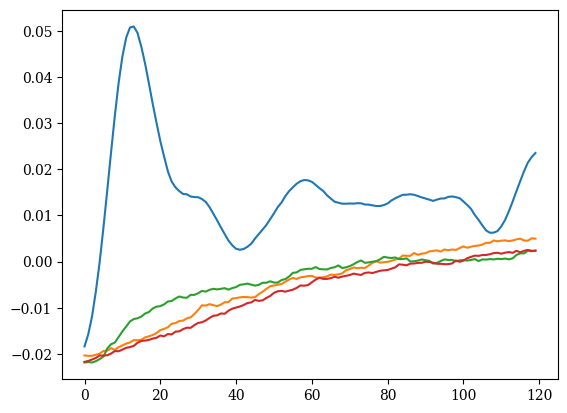

In [18]:
plt.plot(test_avg_traj)
plt.plot(white_noise_model_pop_response['None_stim'].detach())
plt.plot(white_noise_model_pop_response['postsynaptic_stim'].detach())
plt.plot(white_noise_model_pop_response['additive'].detach())
# plt.plot(white_noise_model_pop_response['postsynaptic'].detach())

In [39]:
plot_first_principal_components(trajs, model='None_stim')

NameError: name 'trajs' is not defined

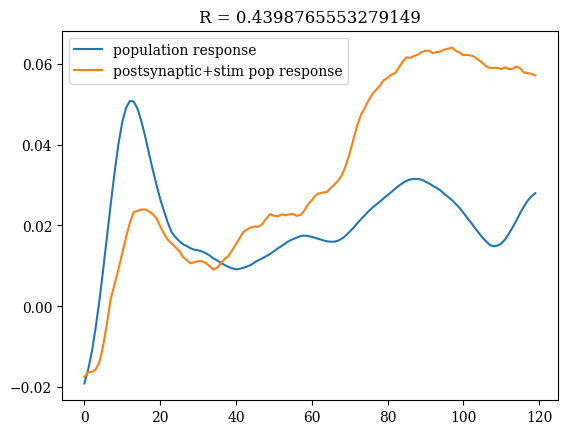

In [283]:
plt.plot(test_avg_traj, label='population response')
plt.plot(white_noise_model_pop_response['postsynaptic_stim'].detach(), label='postsynaptic+stim pop response')
r = pearsonr(test_avg_traj, white_noise_model_pop_response['postsynaptic_stim'].detach())[0]
plt.title(f'R = {r}')
plt.legend()
plt.savefig('white_noise_pop_postsynaptic_stim.png')

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
plot_bar_scatter_sem(ax, r_vals_white_noise, 'R (White noise)', y_label='R')
plt.tight_layout()
plt.show()
fig.savefig('wasserstein_baseline.png')

### Study population responses during airpuffs

In [23]:
# visualize the mean population activity of each model along white noise trials 
airpuff_model_pop_response = {}
for model in avg_trajs.keys():
    model_trajs, test_trajs = [], []
    # for each averaged activity, get the averaged population response 
    for i in range(len(avg_trajs[model])):
        model_trajs.append(avg_trajs[model][i].mean(axis=0))
    # now average this across trials 
    airpuff_model_pop_response[model] = torch.vstack(model_trajs).mean(axis=0)

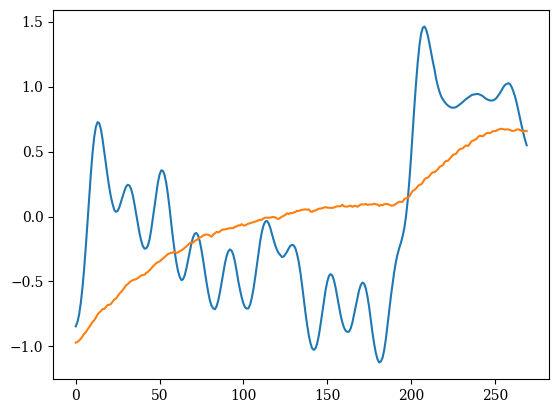

In [33]:
from sklearn.decomposition import PCA

avg_test_traj = np.stack(trajs['test']).mean(axis=0)

pca = PCA(n_components=1)
test_pca_1 = pca.fit_transform(avg_test_traj.T)
plt.plot(test_pca_1.flatten())

none_avg_traj = torch.stack(trajs['additive_stim']).mean(axis=0).detach()
none_pca_1 = pca.fit_transform(none_avg_traj.T)
plt.plot(none_pca_1.flatten())
# pca.fit(X)
# plt.plot(test_avg_traj)
# plt.plot(airpuff_model_pop_response['None_stim'].detach())
# r = pearsonr(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())[0]
# r2 = r2_score(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())
# plt.title(f'R = {r}. R^2 = {r2}')
# plt.legend() 
# plt.savefig('airpuff_pop_none.png')

/tmp/ipykernel_913389/4288926017.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


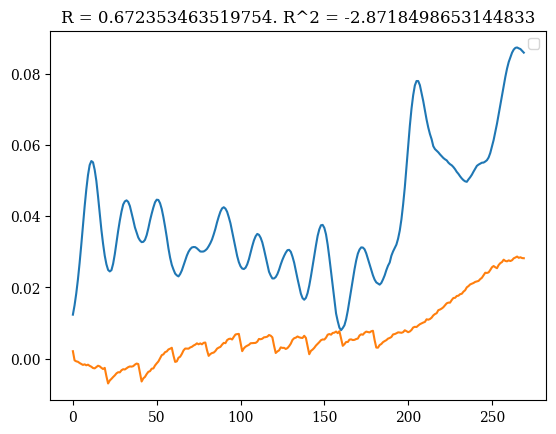

In [25]:
plt.plot(test_avg_traj)
plt.plot(airpuff_model_pop_response['None_stim'].detach())
r = pearsonr(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())[0]
r2 = r2_score(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())
plt.title(f'R = {r}. R^2 = {r2}')
plt.legend()
# plt.savefig('airpuff_pop_postsynaptic.png')

/tmp/ipykernel_913389/2628926860.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


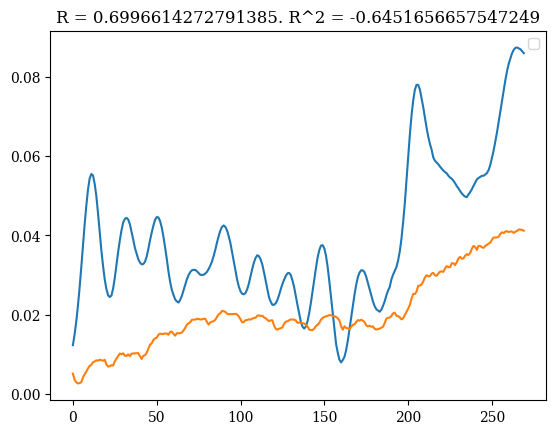

In [26]:
plt.plot(test_avg_traj)
plt.plot(airpuff_model_pop_response['postsynaptic_stim'].detach())
r = pearsonr(test_avg_traj, airpuff_model_pop_response['postsynaptic_stim'].detach())[0]
r2 = r2_score(test_avg_traj, airpuff_model_pop_response['postsynaptic_stim'].detach())
plt.title(f'R = {r}. R^2 = {r2}')
plt.legend()
# plt.savefig('airpuff_pop_postsynaptic_stim.png')

/tmp/ipykernel_913389/4076923274.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


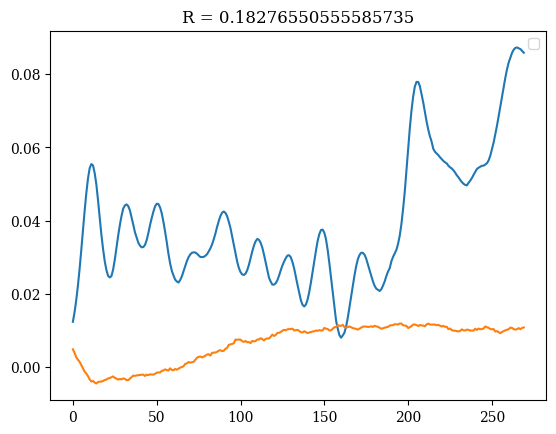

In [27]:
plt.plot(test_avg_traj)
plt.plot(airpuff_model_pop_response['additive'].detach())
r = pearsonr(test_avg_traj, airpuff_model_pop_response['additive'].detach())[0]
plt.title(f'R = {r}')
plt.legend()
# plt.savefig('airpuff_pop_additive.png')

NameError: name 'airpuff_model_pop_response' is not defined

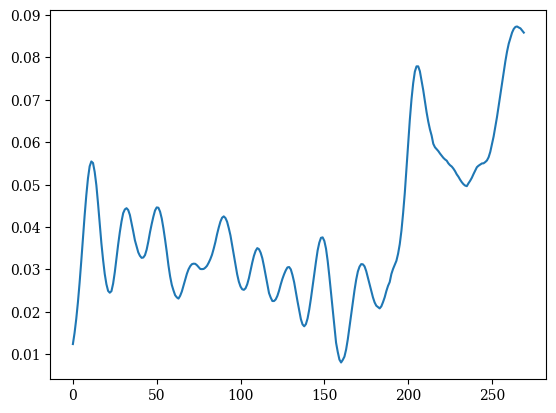

In [22]:
plt.plot(test_avg_traj)
plt.plot(airpuff_model_pop_response['additive_stim'].detach())
r = pearsonr(test_avg_traj, airpuff_model_pop_response['additive_stim'].detach())[0]
plt.title(f'R = {r}')
plt.legend()
# plt.savefig('airpuff_pop_additive_stim.png')

In [201]:
pearsonr(test_avg_traj, airpuff_model_pop_response['postsynaptic_stim'].detach())

PearsonRResult(statistic=0.37931931290838306, pvalue=1.9325797586542102e-05)

In [202]:
pearsonr(test_avg_traj, airpuff_model_pop_response['additive'].detach())

PearsonRResult(statistic=0.37324730533634, pvalue=2.6845814203916095e-05)

In [203]:
pearsonr(test_avg_traj, airpuff_model_pop_response['additive_stim'].detach())

PearsonRResult(statistic=0.44693051352676433, pvalue=3.103030380871955e-07)

In [21]:
np.array(r_vals['None_stim']).mean(), np.array(r_vals['postsynaptic']).mean(), np.array(r_vals['postsynaptic_stim']).mean(), np.array(r_vals['additive']).mean(), np.array(r_vals['additive_stim']).mean()

(0.48886479729362237,
 0.47542828065808307,
 0.567301249964342,
 0.2954328358631417,
 0.5184201551560811)

### Reward

In [35]:
from sklearn.metrics import r2_score 
import warnings
warnings.filterwarnings("ignore")

models = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'additive', 'additive_stim'] 
trajs, r_vals, r2_vals, avg_trajs, test_avg_trajs = {}, {}, {}, {}, []

trajs['test'] = []
for j in range(19, -1):
    t_start, t_end = seq_periods[j]
    trajs['test'].append(x_train[:, t_start:t_end])

for model in models:
    for i in range(0, 10):
        if 'stim' in model:
            model_name = model.split('_')[0]
            vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{model_name}_rank_20_seed_{i}_stim')
        else:
            vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{model}_rank_20_seed_{i}')
                    
        num_trajs = 20
        for j in range(19, len(seq_periods)):
            t_start, t_end = seq_periods[j]
            spike_counts_val = x_train[:, t_start : t_end] 
            if model not in trajs.keys():
                trajs[model] = []
                r_vals[model] = [] 
                r2_vals[model] = []
                avg_trajs[model] = []          
                
            if 'stim' in model:
                stim = torch.from_numpy(stim_arr_train[:, t_start : t_end]).to(torch.float32)
            else: stim = None 
            
            # generate 10 trajectories 
            for _ in range(num_trajs):      
                traj = get_trajectory(t_start, t_end, vae, model, stim, use_index=True)
                trajs[model].append(traj)
            
            # average the trajectories 
            avg_traj = torch.stack(trajs[model][-num_trajs:]).mean(axis=0)
            test_avg_trajs.append(spike_counts_val.mean(axis=0))
            # compute the r
            aligned_traj_gen, aligned_traj_test = None, None 
            for t_start, t_end in reward_eval_blocks[j - 15]:
                if aligned_traj_gen is not None:
                    aligned_traj_gen = torch.hstack([aligned_traj_gen, avg_traj[:, int(t_start):int(t_end)]])
                    aligned_traj_test = np.hstack([aligned_traj_test, spike_counts_val[:, int(t_start):int(t_end)]])
                else: 
                    aligned_traj_gen = avg_traj[:, int(t_start):int(t_end)]
                    aligned_traj_test = spike_counts_val[:, int(t_start):int(t_end)]
            r = pearsonr(aligned_traj_gen.flatten().detach(), aligned_traj_test.flatten())[0]
            print(f'Model {model} Fit {i}, block: {j} r: {r}')
            r2 = r2_score(avg_traj.flatten().detach(), spike_counts_val.flatten())
            r_vals[model].append(r)
            r2_vals[model].append(r2)
            avg_trajs[model].append(avg_traj)
            

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Model None_stim Fit 0, block: 19 r: 0.3548090628776382
Model None_stim Fit 0, block: 20 r: 0.23895415982642265
Model None_stim Fit 0, block: 21 r: 0.1389244238156
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Model None_stim Fit 1, block: 19 r: 0.2621825089711658
Model None_stim Fit 1, block: 20 r: 0.15864683213386566
Model None_stim Fit 1, block: 21 r: 0.1180407691330832
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight

In [36]:
np.array(r_vals['None_stim']).mean(), np.array(r_vals['postsynaptic']).mean(), np.array(r_vals['postsynaptic_stim']).mean(), np.array(r_vals['additive']).mean(), np.array(r_vals['additive_stim']).mean()

(0.16159890240685976,
 0.2380684639810661,
 0.22938016770271163,
 0.1880663416241145,
 0.17470786522689266)

In [122]:
trajs.keys()

dict_keys(['test', 'None_stim'])

KeyError: 'postsynaptic'

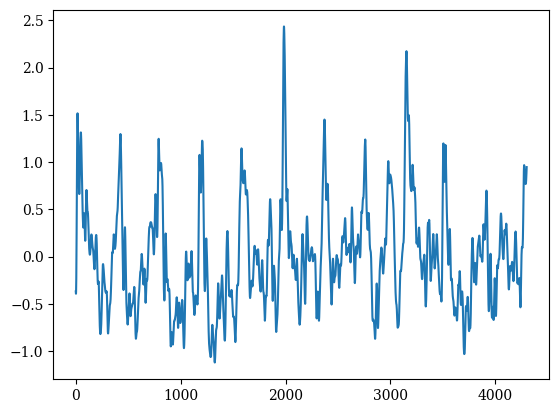

In [121]:
from sklearn.decomposition import PCA

avg_test_traj = np.stack(trajs['test'][1:]).mean(axis=0)

pca = PCA(n_components=1)
test_pca_1 = pca.fit_transform(avg_test_traj.T)
plt.plot(test_pca_1.flatten())

none_avg_traj = torch.stack(trajs['postsynaptic'][1:]).mean(axis=0).detach()
none_pca_1 = pca.fit_transform(none_avg_traj.T)
plt.plot(none_pca_1.flatten())
# pca.fit(X)
# plt.plot(test_avg_traj)
# plt.plot(airpuff_model_pop_response['None_stim'].detach())
# r = pearsonr(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())[0]
# r2 = r2_score(test_avg_traj, airpuff_model_pop_response['None_stim'].detach())
# plt.title(f'R = {r}. R^2 = {r2}')
# plt.legend() 
# plt.savefig('airpuff_pop_none.png')

None_stim
postsynaptic_stim
postsynaptic
no input
additive
no input
additive_stim
presynaptic
no input
rank_stim
rank
no input
2914.88426666667 3090.38426666667


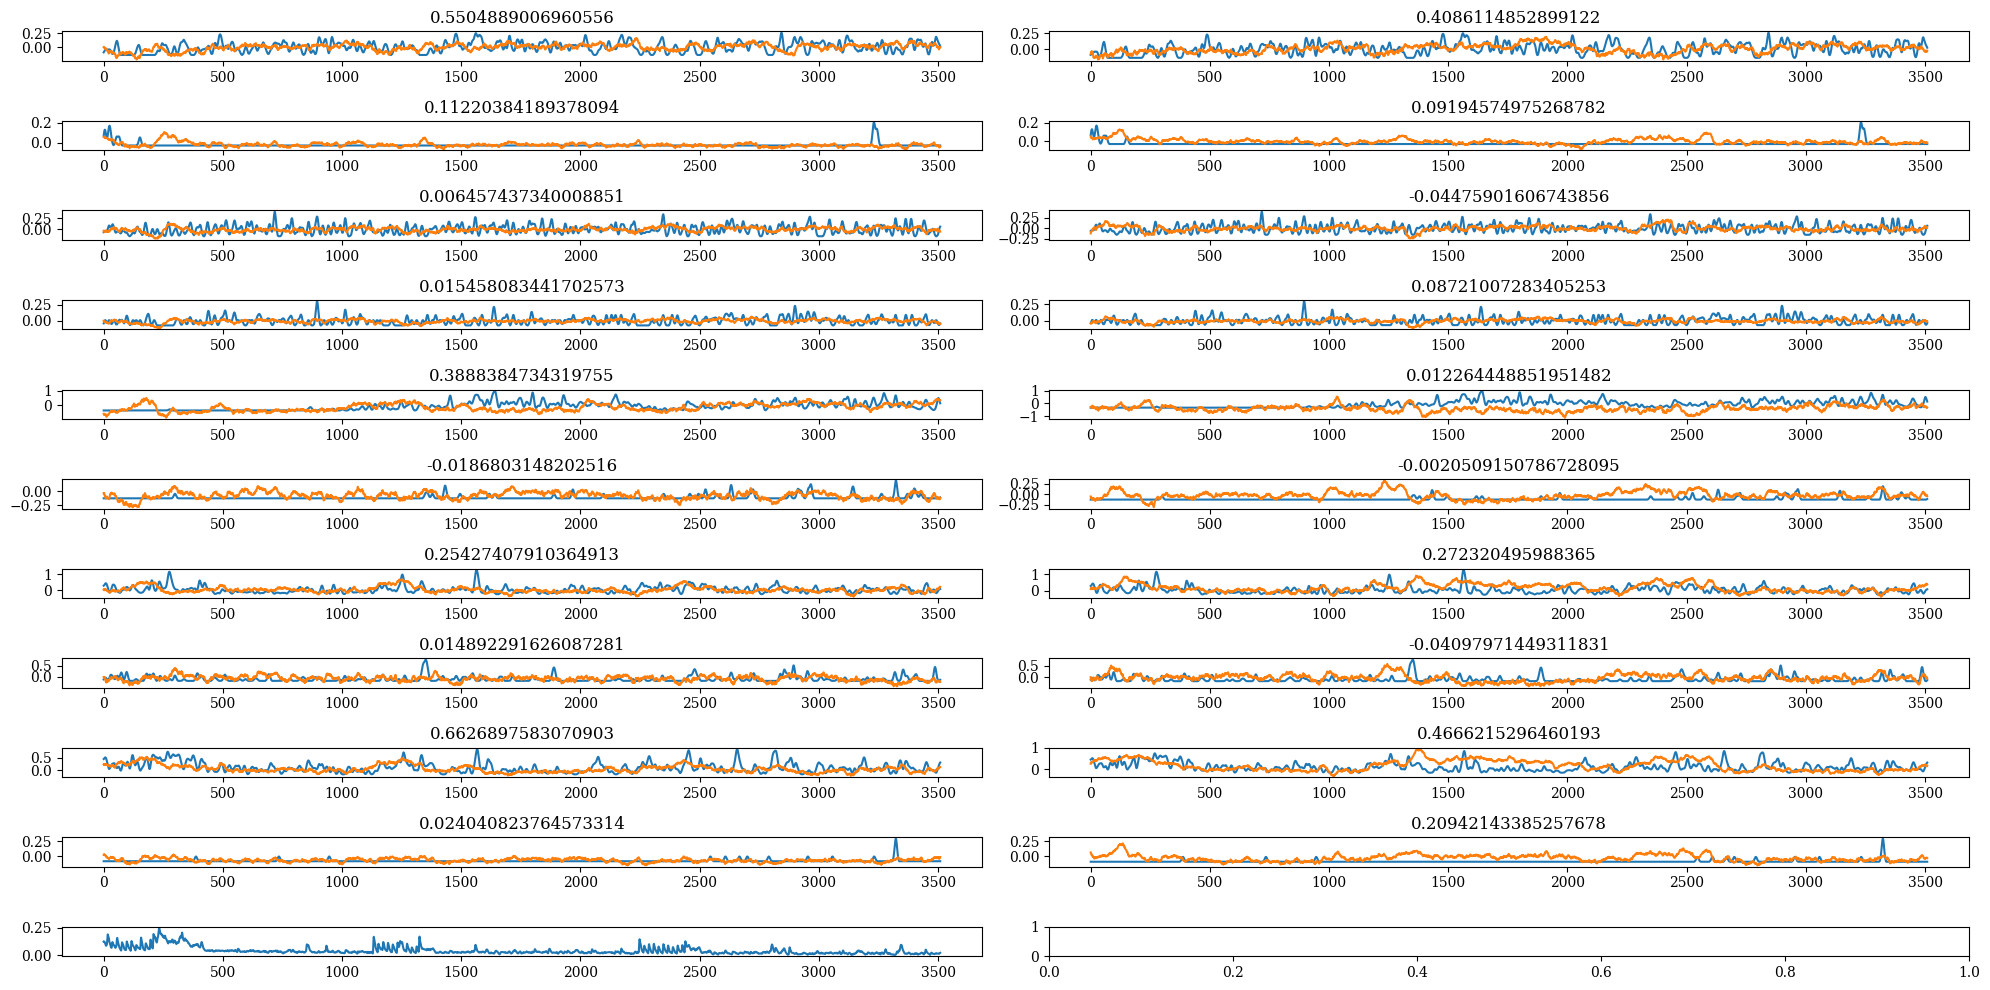

In [35]:
t_start, t_end = airpuff_block[0], airpuff_block[1]
trajs = {}
for i, model in enumerate(models.keys()):
    neuromod = model
    print(neuromod)
    stim = torch.from_numpy(stim_arr_airpuff).to(torch.float32)
    if 'stim' not in neuromod: stim = None
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim)
print(t_start, t_end)
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
fig, ax = plt.subplots(11, 2, figsize=(20, 10))
for i in range(10):
    r_p = pearsonr(spike_counts_val[i+10].flatten(), trajs['postsynaptic_stim'][i+10].detach().flatten())
    r_n = pearsonr(spike_counts_val[i+10].flatten(), trajs['additive_stim'][i+10].detach().flatten())
    
    ax[i,0].plot(spike_counts_val[i])
    ax[i,0].plot(trajs['postsynaptic_stim'][i].detach())
    ax[i,1].plot(spike_counts_val[i])
    ax[i,1].plot(trajs['additive_stim'][i].detach())
    ax[i,0].set_title(r_p[0])
    ax[i,1].set_title(r_n[0])
ax[-1,0].plot(neuromod_val)
plt.tight_layout()

In [128]:
trials_df['trialtype'].unique()

array(['ODOR-ON_1', 'PAUSE_120', 'TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1',
       'TONE_1_LAG_2500', 'TONE_1_LAG_500_REW_2_LAG_2000_VACUUM_1',
       'TONE_1_LAG_500_REW_3_LAG_2000_VACUUM_1', 'TONE_2',
       'TONE_3_LAG_500_AIRPUFF_1', 'PAUSE_300'], dtype=object)

In [127]:
airpuff_trial = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['t'].to_list()
for trial in airpuff_trial:
    t_start, t_end = trial - 5, trial + 5

Index(['id', 't', 'trialtype', 'cs', 'us', 'vacuum', 'opto_on', 'opto_off',
       'ustype', 'us_stop', 'cstype', 'first_lick'],
      dtype='object')

In [50]:
compute_stats(odor_blocks[0][0], odor_blocks[0][1], 'airpuff_1', num_trajs=5)

None
no input
n outliers: 0.0017500000000000293
Sample 0, KL Div: 2.542581558227539, Wasserstein: 2.8506701750975063, r: 0.30092920618382935, PSH: 0.2217498959028715, mean-rate: 15.976445500652744
no input
n outliers: 0.0034999999999999476
Sample 1, KL Div: 2.405735969543457, Wasserstein: 2.718154979721994, r: 0.3199186455808345, PSH: 0.23586405905216462, mean-rate: 14.35436955246209
no input
n outliers: 0.0017500000000000293
Sample 2, KL Div: 2.3981850147247314, Wasserstein: 2.9406919411388, r: 0.3763258787298984, PSH: 0.23904384518151836, mean-rate: 17.348996836655907
no input
n outliers: 0.0030000000000000027
Sample 3, KL Div: 2.519963502883911, Wasserstein: 2.8447438455192278, r: 0.3126710814173366, PSH: 0.24242985229812128, mean-rate: 15.988555222878913
no input
n outliers: 0.003249999999999975
Sample 4, KL Div: 2.7865407466888428, Wasserstein: 3.179095324838463, r: 0.33303338096229673, PSH: 0.23273008521097066, mean-rate: 20.45730118522947
None
KL Div: 2.5306013584136964 std: 0.1

In [65]:
trajs = {}
# fig, ax = plt.subplots(len(list(models.keys())), 2, figsize=(8,12))
t_start, t_end = airpuff_block[0], airpuff_block[1]
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
for i, model in enumerate(models.keys()):
    print(model)
    neuromod = model
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim_idx=-1)

None
no input
additive
no input
postsynaptic
no input
presynaptic
no input
rank
no input


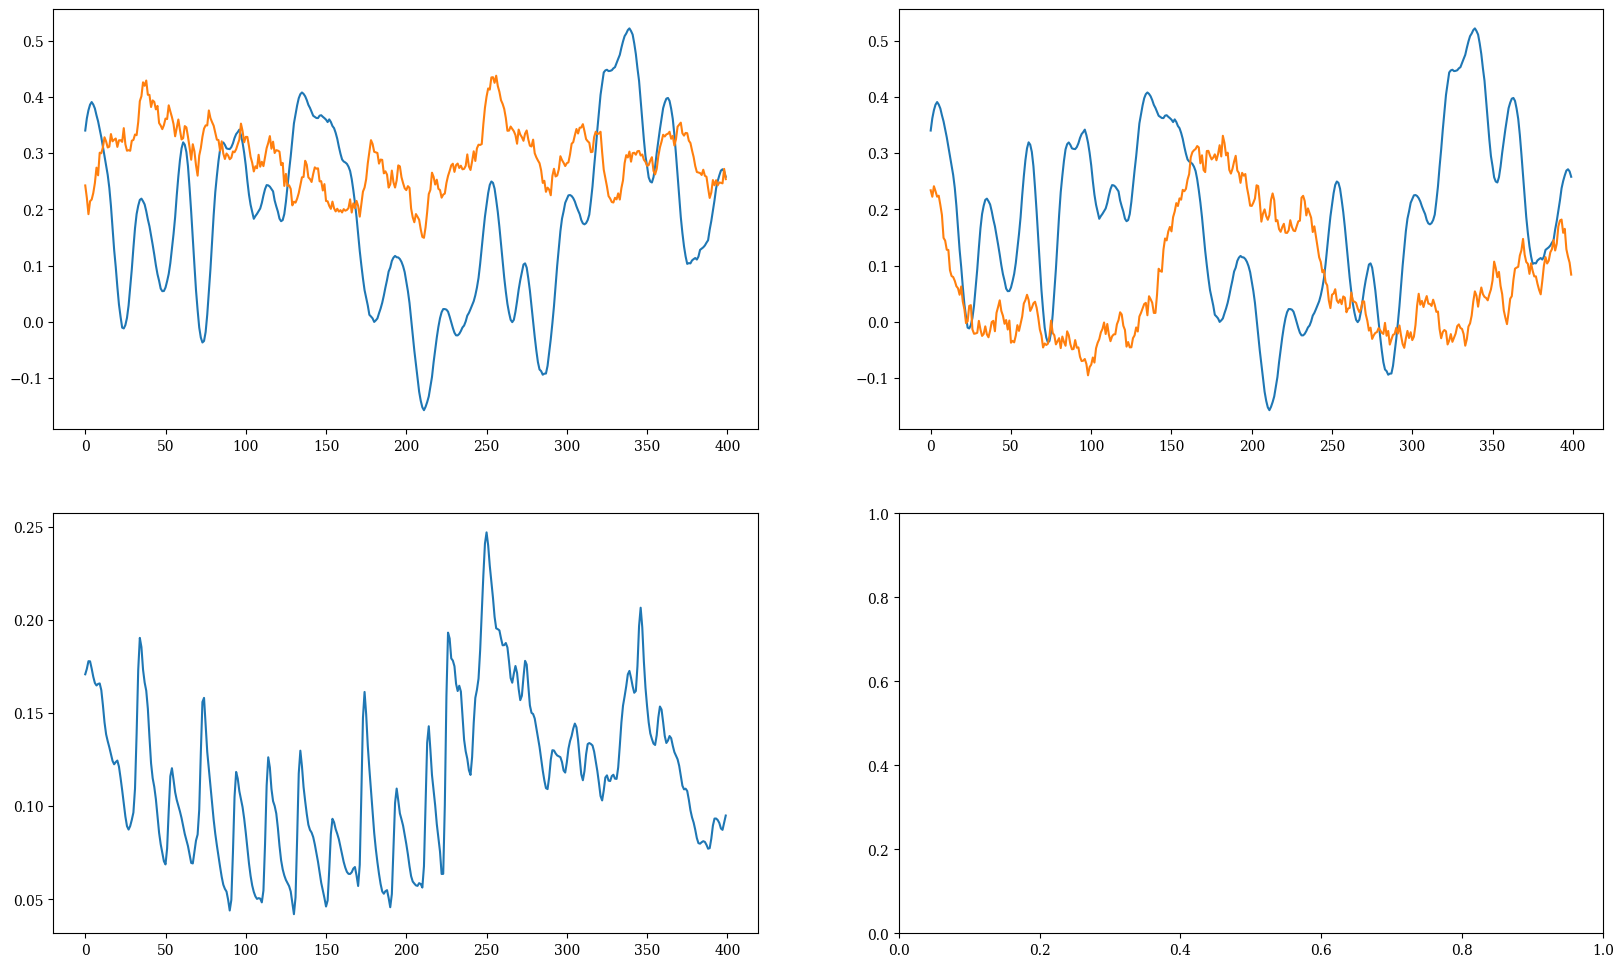

In [259]:
neuron_idx = 61
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
ax[0, 0].plot(spike_counts_val[neuron_idx])
ax[0, 0].plot(trajs['postsynaptic'][neuron_idx].detach())
ax[0, 1].plot(spike_counts_val[neuron_idx])
ax[0, 1].plot(trajs['None'][neuron_idx].detach())
ax[1, 0].plot(neuromod_val)

In [36]:
from sklearn.metrics import r2_score
# compute R for all neurons

prs_post, prs_post_stim, prs_none = [], [], []
r2s_add, r2s_pre, r2s_rank = [], [], []

# nm_neurons = torch.argsort(models['additive'].rnn.transition.A[:, 0].abs(), descending=True)
eval_count = -1

for i in range(spike_counts_val.shape[0]):
    # pr_add = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['additive'][nm_neurons[i]].flatten().detach())[0]
    # pr_pre = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['presynaptic'][nm_neurons[i]].flatten().detach())[0]
    # pr_post = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['postsynaptic'][nm_neurons[i]].flatten().detach())[0]
    # pr_rank = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['rank'][nm_neurons[i]].flatten().detach())[0]

    # pr_add = pearsonr(spike_counts_val[i].flatten(), trajs['additive'][i].flatten().detach())[0]
    pr_post = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic'][i].flatten().detach())[0]
    pr_post_stim = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic_stim'][i].flatten().detach())[0]
    # pr_rank = pearsonr(spike_counts_val[i].flatten(), trajs['rank'][i].flatten().detach())[0]
    pr_none = pearsonr(spike_counts_val[i].flatten(), trajs['None_stim'][i].flatten().detach())[0]
    # r2_add = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[0]][nm_neurons[i]].flatten().detach())[0]
    # r2_pre = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[2]][nm_neurons[i]].flatten().detach())[0]
    # r2_rank = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[3]][nm_neurons[i]].flatten().detach())[0]
    
    # prs_add.append(pr_add)
    prs_post.append(pr_post)
    # prs_rank.append(pr_rank)
    prs_post_stim.append(pr_post_stim)
    prs_none.append(pr_none)
    
    # r2s_add.append(r2_add)
    # r2s_pre.append(r2_pre)
    # r2s_rank.append(r2_rank)

prs_post = np.nan_to_num(prs_post)
prs_post_stim = np.nan_to_num(prs_post_stim)
prs_none = np.nan_to_num(prs_none)

prs_post, prs_post_stim, prs_none = np.array(prs_post), np.array(prs_post_stim), np.array(prs_none)
print(prs_post.mean(), prs_post.std())
print(prs_post_stim.mean(), prs_post_stim.std())
print(prs_none.mean(), prs_none.std())


0.1918461079956062 0.21079314603306684
0.23368979403681908 0.22869315961174694
0.04429139024210413 0.12435710122104371


/tmp/ipykernel_811675/1657303872.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_post = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic'][i].flatten().detach())[0]
/tmp/ipykernel_811675/1657303872.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_post_stim = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic_stim'][i].flatten().detach())[0]
/tmp/ipykernel_811675/1657303872.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_none = pearsonr(spike_counts_val[i].flatten(), trajs['None_stim'][i].flatten().detach())[0]


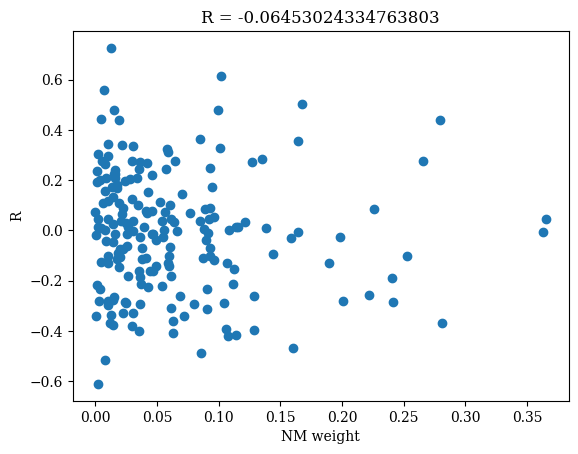

In [67]:
plt.scatter(models['additive'].rnn.transition.A[nm_neurons].abs().detach(), prs_add)
prs_add = np.nan_to_num(prs_add)
r = pearsonr(models['additive'].rnn.transition.A[nm_neurons].abs().detach().flatten(), prs_add)[0]
plt.title(f'R = {r}')
plt.ylabel('R')
plt.xlabel('NM weight')
plt.savefig('RvsNM.png')

Text(0.5, 1.0, 'R = 0.48450503955096835')

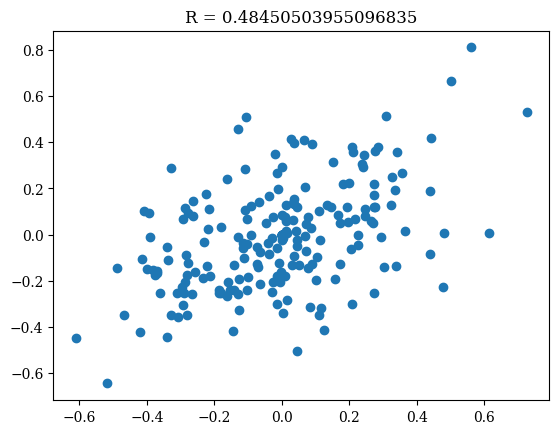

In [68]:
prs_none = np.nan_to_num(prs_none)
prs_add = np.nan_to_num(prs_add)
plt.scatter(prs_add, prs_none)
r = pearsonr(prs_none, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_none.png')

Text(0.5, 1.0, 'R = -0.024641234199474255')

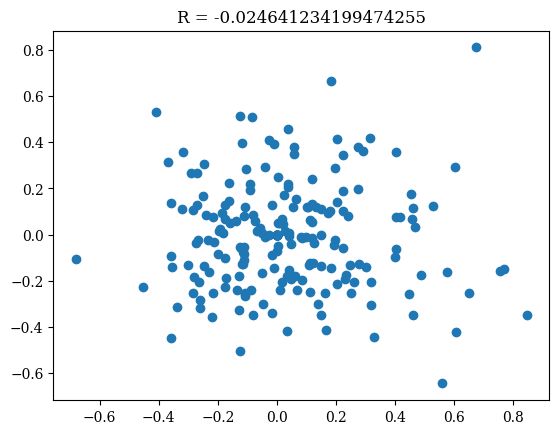

In [69]:
prs_none = np.nan_to_num(prs_none)
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_pre, prs_none)
r = pearsonr(prs_none, prs_pre)
plt.title(f'R = {r[0]}')
# plt.savefig('R_pre_vs_none.png')

Text(0.5, 1.0, 'R = -0.11609061783858497')

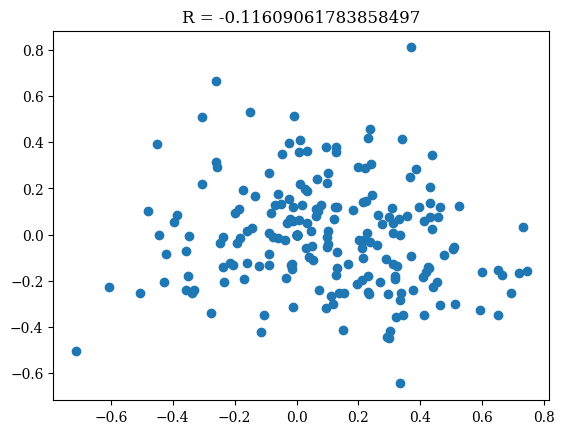

In [70]:
prs_none = np.nan_to_num(prs_none)
prs_post = np.nan_to_num(prs_post)
plt.scatter(prs_post, prs_none)
r = pearsonr(prs_none, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_post_vs_none.png')

Text(0.5, 1.0, 'R = -0.05225042496650859')

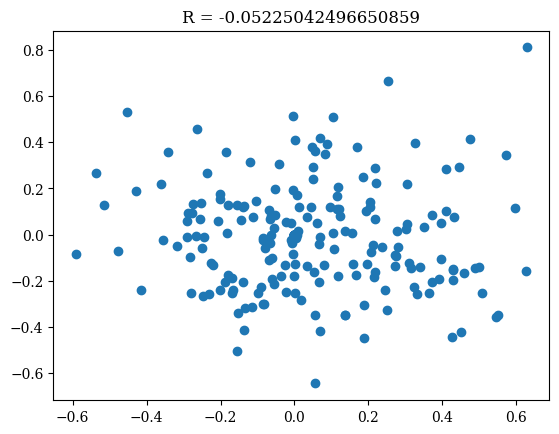

In [71]:
prs_none = np.nan_to_num(prs_none)
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_rank, prs_none)
r = pearsonr(prs_none, prs_rank)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_none.png')

Text(0.5, 1.0, 'R = -0.13505273976144935')

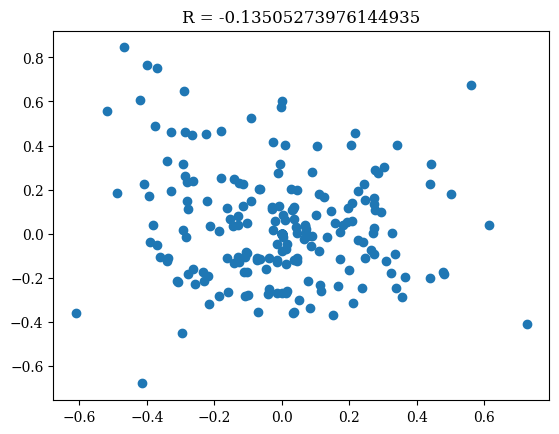

In [72]:
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_add, prs_pre)
r = pearsonr(prs_pre, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_pre.png')

Text(0.5, 1.0, 'R = -0.2360344818534013')

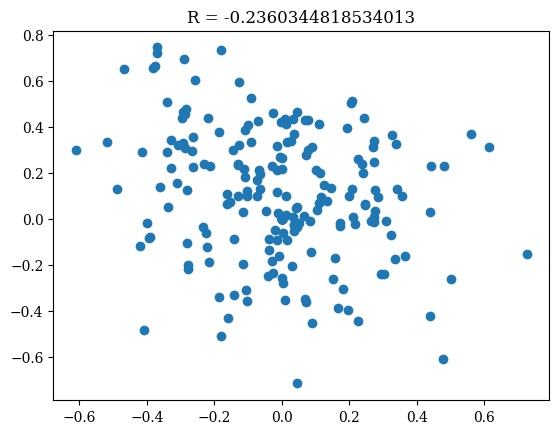

In [73]:
prs_post = np.nan_to_num(prs_post)
plt.scatter(prs_add, prs_post)
r = pearsonr(prs_post, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_post.png')

Text(0.5, 1.0, 'R = 0.20242007189266847')

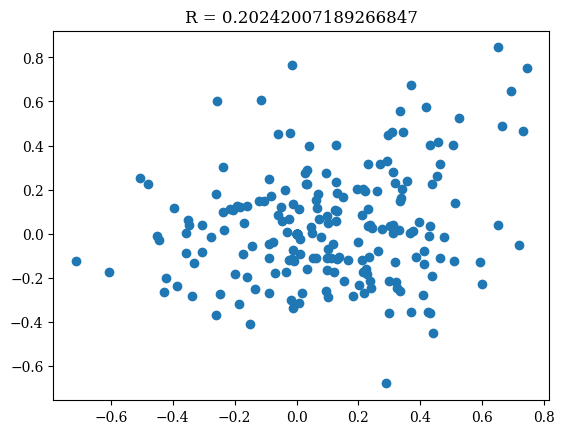

In [74]:
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_post, prs_pre)
r = pearsonr(prs_pre, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_post_vs_pre.png')

Text(0.5, 1.0, 'R = -0.2773955851405411')

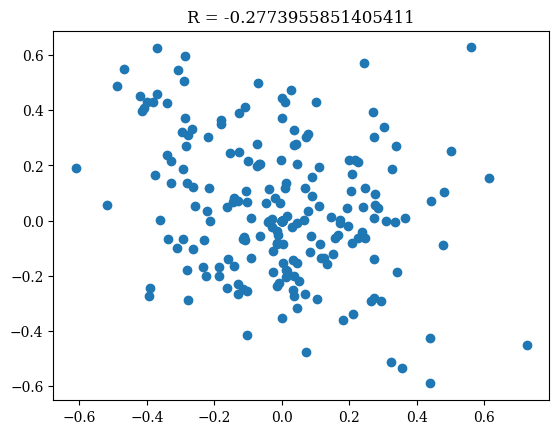

In [75]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_add, prs_rank)
r = pearsonr(prs_rank, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_rank.png')

Text(0.5, 1.0, 'R = 0.3452199263972028')

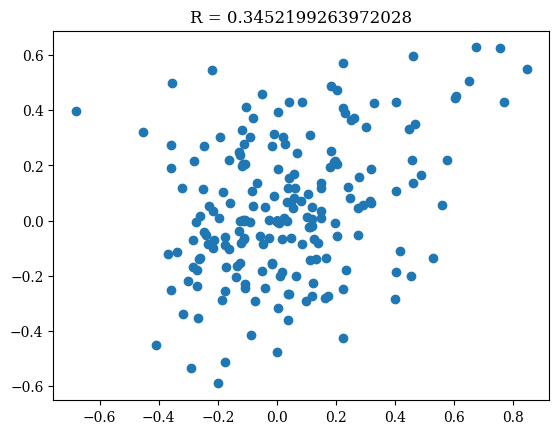

In [76]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_pre, prs_rank)
r = pearsonr(prs_rank, prs_pre)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_pre.png')

Text(0.5, 1.0, 'R = 0.43076061859176606')

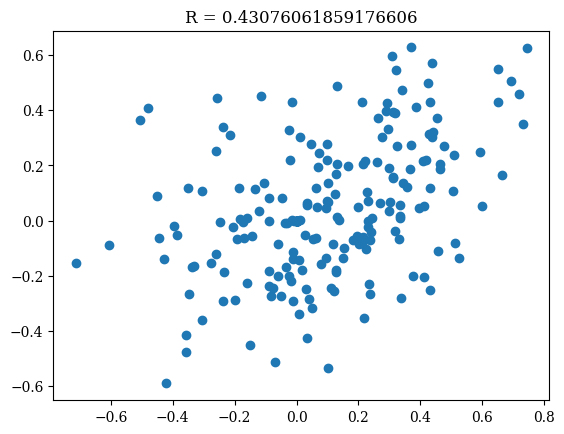

In [77]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_post, prs_rank)
r = pearsonr(prs_rank, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_post.png')

<Axes: >

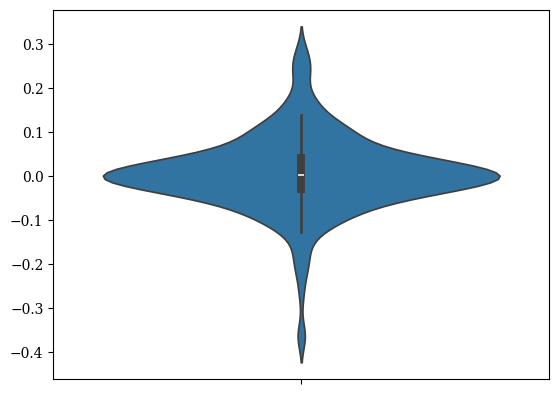

In [78]:
sns.violinplot(models['additive'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_additive.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efbeb8b2080>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb8b1210>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efbeb8b1f60>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb8b1b10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb8b3b50>],
 'means': []}

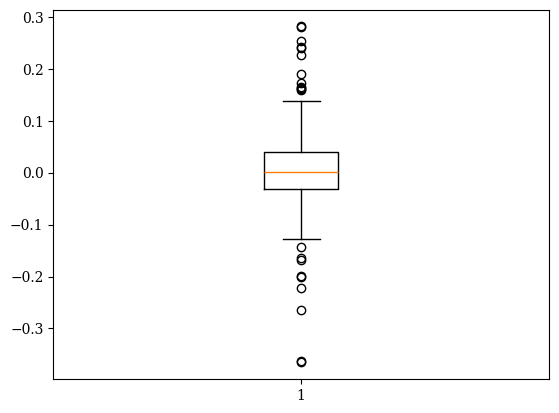

In [79]:
plt.boxplot(models['additive'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_additive.png')

<Axes: >

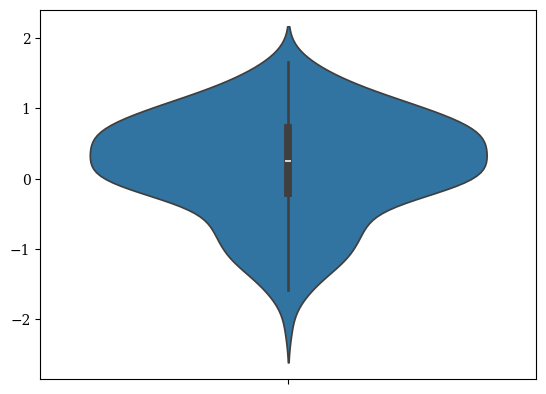

In [80]:
sns.violinplot(models['postsynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_postsynaptic.png')

<Axes: >

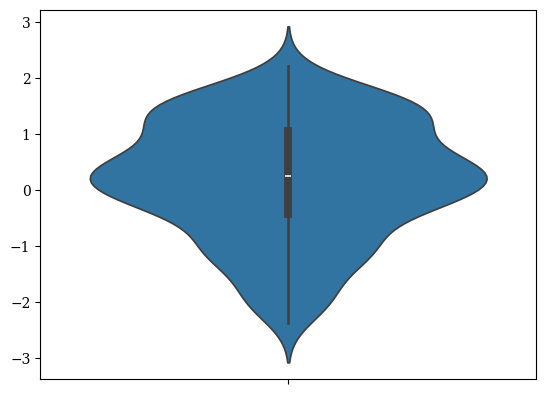

In [81]:
sns.violinplot(models['presynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_presynaptic.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efb55e5bbb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb23c0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efb55e5b8b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb23c6d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb23c9d0>],
 'means': []}

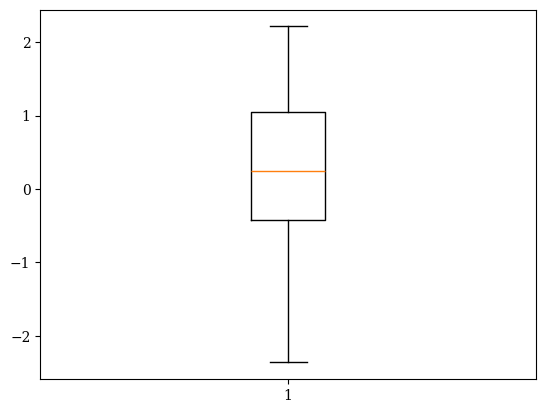

In [82]:
plt.boxplot(models['presynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_presynaptic.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efbeb1eda50>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb1ee050>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efbeb1ed750>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb1ee650>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb1ee890>],
 'means': []}

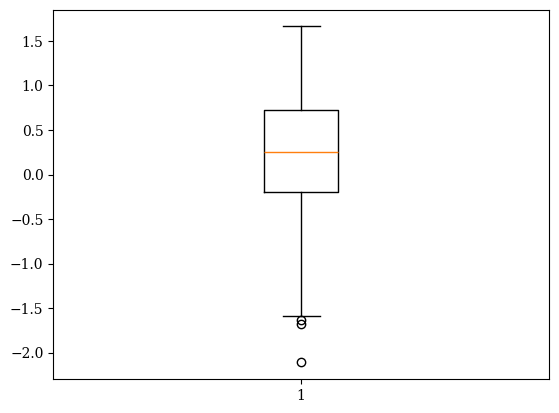

In [83]:
plt.boxplot(models['postsynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_postsynaptic.png')

In [117]:
locations = np.array(['null' for i in range(spike_counts_val.shape[0])])
locations[0:95] = 'DTT'
locations[95:142] = 'DP'
locations[142:167] = 'IL'
locations[167:190] = 'PL'
locations[190:226] = 'Cg'
locations[226:] = 'M2'

## Analysis of models trained on baseline and white noise period

In [175]:
odor_blocks

[[620, 640], [661, 681], [702, 722], [4642, 4662], [4683, 4703], [4724, 4744]]

In [177]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
spike_counts_white_noise_1, s_white_noise_1 = get_block(spike_counts, neuromod_activity, white_noise_blocks[0][0], white_noise_blocks[3][1])
spike_counts_airpuff_1, s_airpuff_1 = get_block(spike_counts, neuromod_activity, airpuff_blocks[0][0], airpuff_blocks[2][1])
spike_counts_odor_1, s_odor_1 = get_block(spike_counts, neuromod_activity, odor_blocks[0][0], odor_blocks[2][1])
spike_counts_reward_1, s_reward_1 = get_block(spike_counts, neuromod_activity, reward_blocks[0][0], reward_blocks[3][1])

s_min = np.min([s_pt_baseline.min(), s_white_noise_1.min(), s_airpuff_1.min(), s_odor_1.min(), s_reward_1.min()])
s_max = np.max([s_pt_baseline.max(), s_white_noise_1.max(), s_airpuff_1.max(), s_odor_1.max(), s_reward_1.max()])

s_pt_baseline = (s_max - s_min) / (s_max - s_min)
s_white_noise_1 = (s_max - s_min) / (s_max - s_min) 
s_airpuff_1 = (s_max - s_min) / (s_max - s_min) 
s_odor_1 = (s_max - s_min) / (s_max - s_min)
s_reward_1 = (s_max - s_min) / (s_max - s_min)

spike_counts_train = np.hstack([spike_counts_pt_baseline, spike_counts_white_noise_1, spike_counts_airpuff_1, spike_counts_odor_1, spike_counts_reward_1])
s_train = np.hstack([s_pt_baseline, s_white_noise_1, s_airpuff_1, s_odor_1, s_reward_1])

In [163]:
models = {}
neuromodulation = ['None', 'postsynaptic', 'presynaptic', 'rank']
for neuromod in neuromodulation:
    try:
        vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{neuromod}_rank_4_multi_block')
            
        models[neuromod] = vae
    except: 
        print(f'Not found: {neuromod}')  


dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: presynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: rank
using clipped ReLU activation
using uniform init
weight scaler 1


In [164]:
models.keys()

dict_keys(['None', 'postsynaptic', 'presynaptic', 'rank'])

In [160]:
models['presynaptic'].rnn.transition.Wu.shape

torch.Size([231, 5])

In [179]:
t_start, t_end = t_start_post_trial - 600, t_start_post_trial
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
print(t_start, t_end)
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)

6369 6669


In [84]:
trajs = {}
# fig, ax = plt.subplots(len(list(models.keys())), 2, figsize=(8,12))
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
for i, model in enumerate(models.keys()):
    print(model)
    neuromod = model
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim_idx=0)


None
no input
additive
no input
postsynaptic
no input
presynaptic
no input
rank
no input


/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


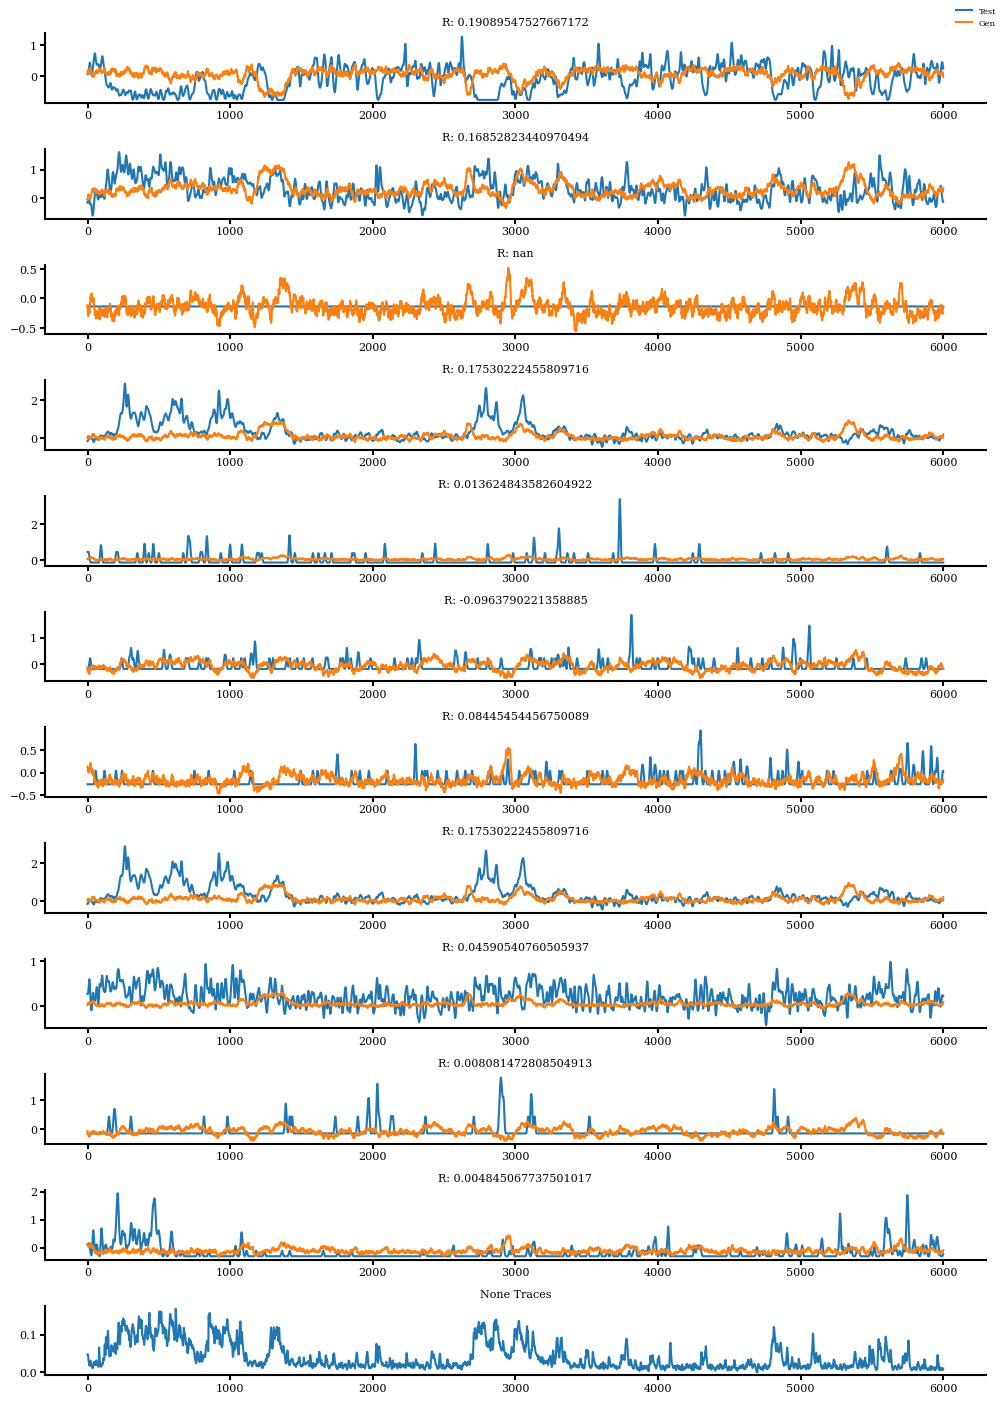

In [167]:
neurons = [172, 50, 15, 167, 30, 40, 80, 167, 90, 200, 10]
plot_traces(neurons, trajs['None'], spike_counts_val, neuromod_val, 'None')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


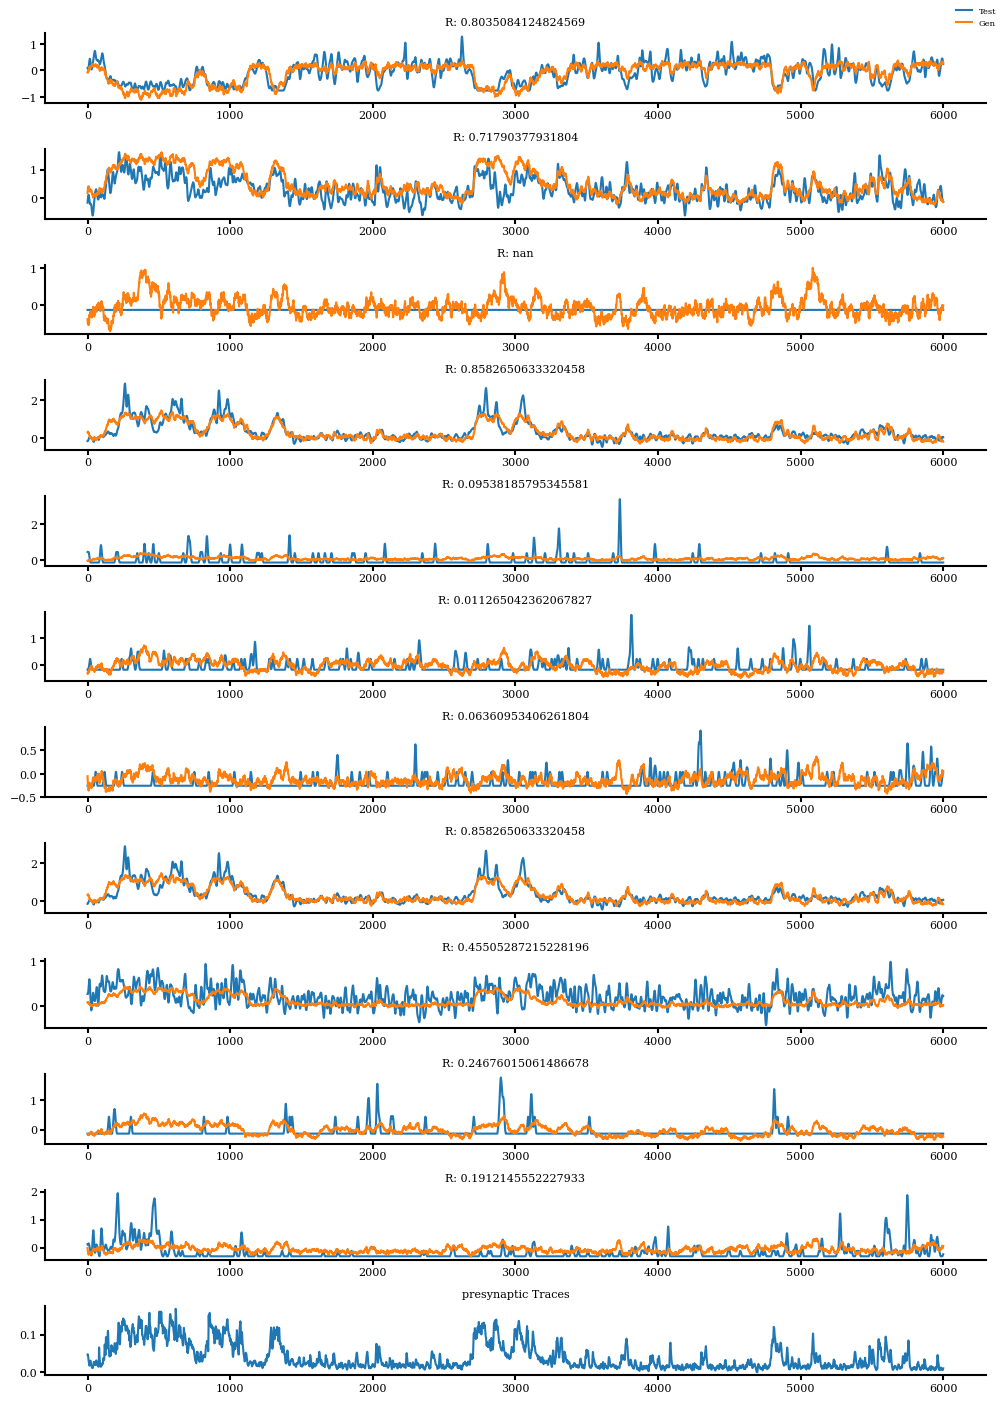

In [168]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'presynaptic')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


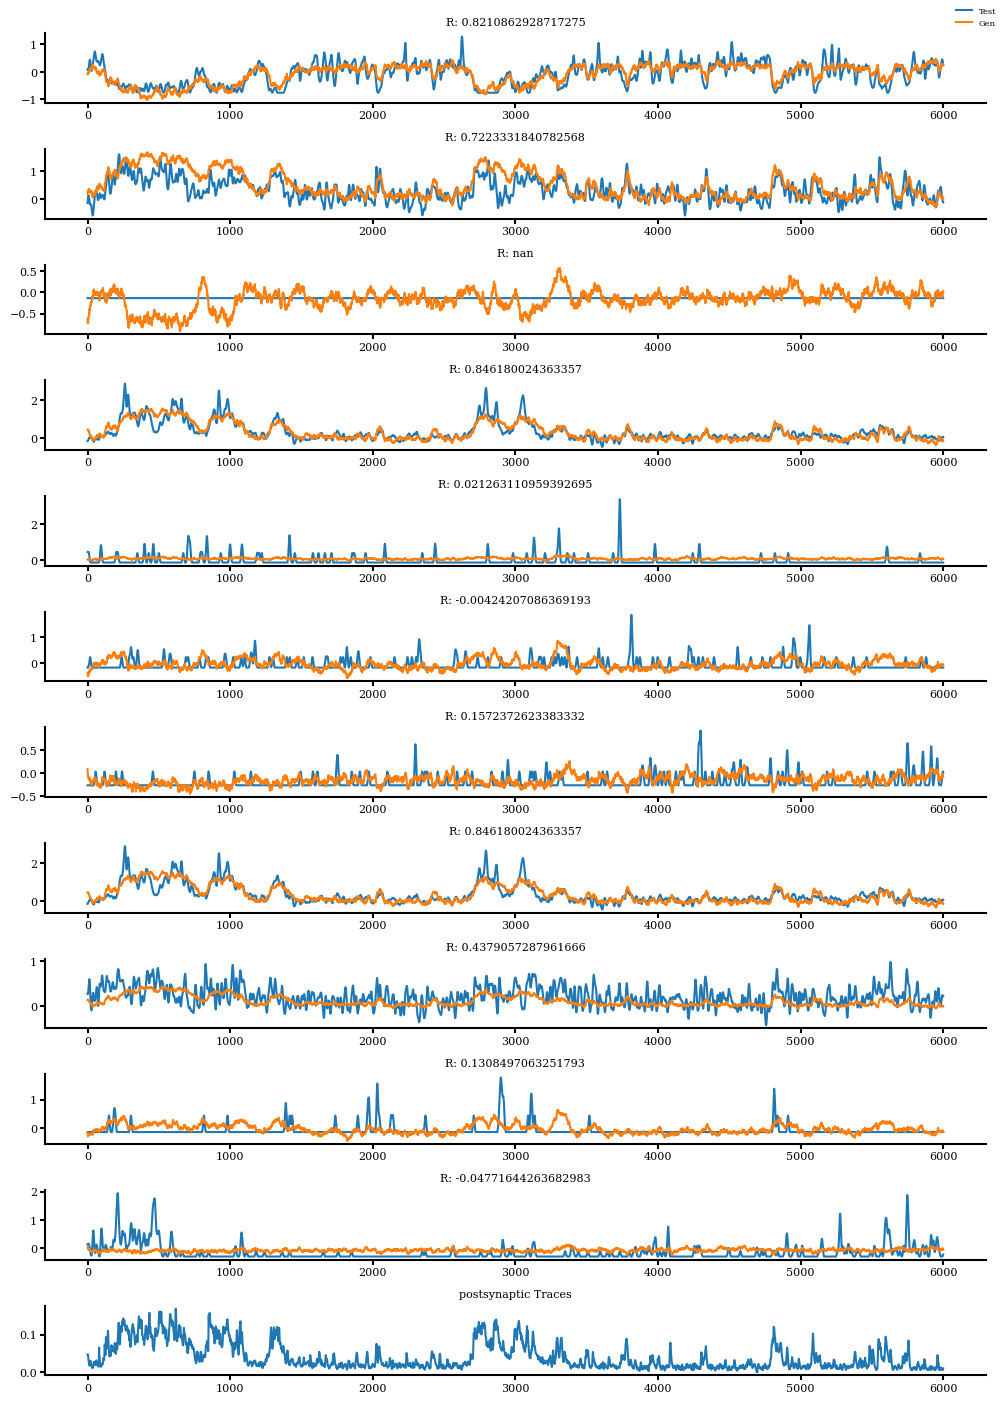

In [169]:
plot_traces(neurons, trajs['postsynaptic'], spike_counts_val, neuromod_val, 'postsynaptic')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


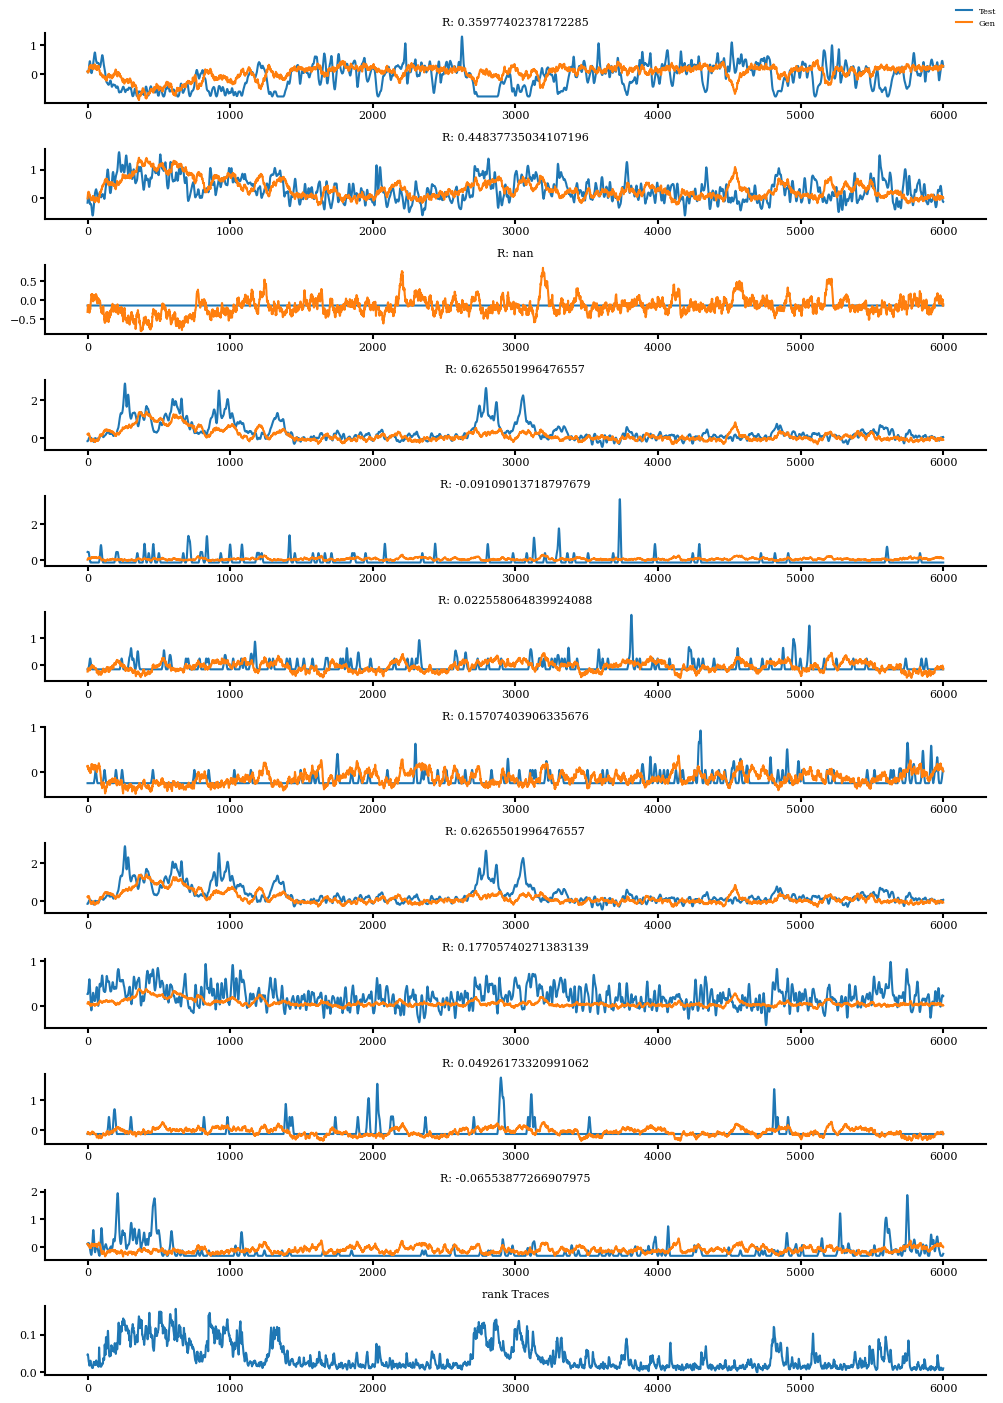

In [181]:
plot_traces(neurons, trajs['rank'], spike_counts_val, neuromod_val, 'rank')

### Compute stats for validation period

In [189]:
compute_stats(t_start_post_trial - 900, t_start_post_trial, 'validation', num_trajs=5, stim_idx=0)

None
n outliers: 0.96975
Sample 0, KL Div: 1.1965466737747192, Wasserstein: 4.670493015725777, r: 0.5562049367420595, PSH: 0.24233645514419125, mean-rate: 179.64935431677463
n outliers: 0.9765
Sample 1, KL Div: 1.0739612579345703, Wasserstein: 4.567135561265078, r: 0.5551511864780264, PSH: 0.24283987541098123, mean-rate: 187.82443700412324
n outliers: 0.975
Sample 2, KL Div: 1.3255330324172974, Wasserstein: 4.5594336478633, r: 0.5553305877327995, PSH: 0.24219192010900942, mean-rate: 180.6851236277217
n outliers: 0.975
Sample 3, KL Div: 0.8310631513595581, Wasserstein: 4.699804776600444, r: 0.5605053248121112, PSH: 0.24221672553339113, mean-rate: 177.01354414655808
n outliers: 0.97525
Sample 4, KL Div: 1.2825889587402344, Wasserstein: 4.48550508960762, r: 0.5534969234651925, PSH: 0.2435958376437699, mean-rate: 175.9135308662748
None
KL Div: 1.141938614845276 std: 0.17761528332406912
Wasserstein dist: 4.596474418212444 std: 0.07836184636476436
Mean rate error: 180.2171979922905 std: 4.17

In [172]:
compute_stats(white_noise_blocks[4][0], white_noise_blocks[-1][1], 'wn_white_noise', num_trajs=5, stim_idx=1)

None
n outliers: 0.982
Sample 0, KL Div: 2.3475658893585205, Wasserstein: 5.514312876074141, r: 0.40013248615697183, PSH: 0.2502857814315793, mean-rate: 96.92219300023561
n outliers: 0.9835
Sample 1, KL Div: 2.6472246646881104, Wasserstein: 5.642112671443937, r: 0.3807835824290695, PSH: 0.25035132630620743, mean-rate: 106.9817751301165
n outliers: 0.98725
Sample 2, KL Div: 2.1875510215759277, Wasserstein: 5.6139846759076315, r: 0.385000787794307, PSH: 0.24971197840886467, mean-rate: 107.08944535930824
n outliers: 0.98325
Sample 3, KL Div: 2.403130292892456, Wasserstein: 5.795287980546943, r: 0.36594145463570854, PSH: 0.25143458610394503, mean-rate: 124.18689063434502
n outliers: 0.983
Sample 4, KL Div: 2.288914442062378, Wasserstein: 5.559730849678189, r: 0.3770867467358233, PSH: 0.24890235516747128, mean-rate: 97.71289441831192
None
KL Div: 2.3748772621154783 std: 0.15375173452301402
Wasserstein dist: 5.625085810730168 std: 0.09583719713855032
Mean rate error: 106.57863970846347 std: 

In [173]:
compute_stats(airpuff_blocks[3][0], airpuff_blocks[-1][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=2)

None
n outliers: 0.98125
Sample 0, KL Div: 0.8127425909042358, Wasserstein: 5.387342503334823, r: 0.5469553171905233, PSH: 0.24324239616262336, mean-rate: 55.24170511477
n outliers: 0.9795
Sample 1, KL Div: 1.482690453529358, Wasserstein: 5.287692822980489, r: 0.5126019418204715, PSH: 0.23893972562328866, mean-rate: 51.389415542138714
n outliers: 0.9795
Sample 2, KL Div: 1.508624792098999, Wasserstein: 5.195634900995861, r: 0.5103662859941661, PSH: 0.24000861541755716, mean-rate: 44.08051852666714
n outliers: 0.98575
Sample 3, KL Div: 1.3563071489334106, Wasserstein: 5.211938937207543, r: 0.525940604859808, PSH: 0.24364227004770847, mean-rate: 47.12697440352802
n outliers: 0.98375
Sample 4, KL Div: 1.6292064189910889, Wasserstein: 5.26633575351857, r: 0.5141360314095245, PSH: 0.237040771101358, mean-rate: 47.70900817232782
None
KL Div: 1.3579142808914184 std: 0.2860408817207516
Wasserstein dist: 5.269788983607457 std: 0.06781851974066373
Mean rate error: 49.109524351886336 std: 3.84667

In [184]:
reward_blocks

[[865, 885],
 [884, 904],
 [903, 923],
 [923, 943],
 [1039, 1059],
 [1058, 1078],
 [1078, 1098],
 [1219, 1239],
 [1238, 1258],
 [1258, 1278],
 [1277, 1297],
 [1393, 1413],
 [1413, 1433],
 [1432, 1452],
 [1573, 1593],
 [1592, 1612],
 [1612, 1632],
 [1631, 1651],
 [1747, 1767],
 [1767, 1787],
 [1786, 1806],
 [1927, 1947],
 [1947, 1967],
 [1966, 1986],
 [1985, 2005],
 [2102, 2122],
 [2121, 2141],
 [2140, 2160],
 [2550, 2570],
 [2570, 2590],
 [2589, 2609],
 [2608, 2628],
 [2725, 2745],
 [2744, 2764],
 [2763, 2783],
 [3194, 3214],
 [3213, 3233],
 [3232, 3252],
 [3252, 3272],
 [3368, 3388],
 [3387, 3407],
 [3406, 3426],
 [4106, 4126],
 [4125, 4145],
 [4145, 4165],
 [4164, 4184],
 [4280, 4300],
 [4300, 4320],
 [4319, 4339]]

In [185]:
compute_stats(odor_blocks[0][0], odor_blocks[2][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=3)

None
n outliers: 0.96475
Sample 0, KL Div: 0.7415079474449158, Wasserstein: 4.0498165668756085, r: 0.3615854183769701, PSH: 0.18321685006602487, mean-rate: 2.9049687166171396
n outliers: 0.96575
Sample 1, KL Div: 0.3292387127876282, Wasserstein: 4.1188863243453016, r: 0.3401477133313884, PSH: 0.1807545809229789, mean-rate: 5.572854842504378
n outliers: 0.9655
Sample 2, KL Div: 0.6169199347496033, Wasserstein: 4.0558934936036755, r: 0.37030572300306475, PSH: 0.18971744553347714, mean-rate: 1.7511314108018774
n outliers: 0.9652499999999999
Sample 3, KL Div: 1.1674253940582275, Wasserstein: 4.0971129254797445, r: 0.36944543683795805, PSH: 0.18978600474678617, mean-rate: 1.7209679815912564
n outliers: 0.96475
Sample 4, KL Div: 0.5118655562400818, Wasserstein: 4.018454454011927, r: 0.3631100541711306, PSH: 0.18523737717287106, mean-rate: 0.9356931226200562
None
KL Div: 0.6733915090560914 std: 0.2815777505508053
Wasserstein dist: 4.068032752863251 std: 0.03569016933606188
Mean rate error: 2.

KeyboardInterrupt: 

In [187]:
compute_stats(reward_blocks[4][0], reward_blocks[7][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=4)

None
n outliers: 0.9795
Sample 0, KL Div: 1.4172937870025635, Wasserstein: 5.060168632345354, r: 0.45835210338165233, PSH: 0.2176219617123319, mean-rate: 82.9620732329982
n outliers: 0.9785
Sample 1, KL Div: 1.8406709432601929, Wasserstein: 5.180433338643134, r: 0.4639767808543014, PSH: 0.21774669583132789, mean-rate: 95.67710238066796
n outliers: 0.98025
Sample 2, KL Div: 1.9882924556732178, Wasserstein: 5.040967267637822, r: 0.44837912041133243, PSH: 0.21328632272316034, mean-rate: 83.57680700217904
n outliers: 0.98075
Sample 3, KL Div: 1.7760347127914429, Wasserstein: 5.051536504084917, r: 0.45465652558693903, PSH: 0.21779974442445696, mean-rate: 87.34364503631912
n outliers: 0.979
Sample 4, KL Div: 1.4983490705490112, Wasserstein: 5.061201161959649, r: 0.45287606898829375, PSH: 0.21394013141378593, mean-rate: 86.87414490975605
None
KL Div: 1.7041281938552857 std: 0.21409475571267472
Wasserstein dist: 5.078861380934176 std: 0.05130453682513373
Mean rate error: 87.28675451238408 std: